# Projet Final : Audit Data Complet d'une Marketplace E-commerce

**Analyse avancée du dataset Olist Brazilian E-commerce — 109,320 commandes analysées**

Analyse complète de la marketplace Olist couvrant 5 étapes : importation, nettoyage, construction, exploration, et synthèse des problèmes critiques identifiés.

---

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import geopandas as gpd
import sklearn 

## Étape 1 : Compréhension, chargement et exploration des données

### 1.1 Importation des bibliothèques

In [3]:
geolocation  = pd.read_csv('olist_geolocation_dataset.csv')
items   = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
customers  = pd.read_csv('olist_customers_dataset.csv') 
reviews  = pd.read_csv('olist_order_reviews_dataset.csv')
orders   = pd.read_csv('olist_orders_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers  = pd.read_csv('olist_sellers_dataset.csv')
category = pd.read_csv('product_category_name_translation.csv')

### 1.2 Récapitulatif des données source

In [4]:
tables_meta = {
    'geolocation': {
        'df'      : geolocation,
        'fichier' : 'olist_geolocation_dataset.csv',
        'pk'      : 'geolocation_zip_code_prefix',
        'jointure': 'customer_zip_code_prefix / seller_zip_code_prefix'
    },
    'items': {
        'df'      : items,
        'fichier' : 'olist_order_items_dataset.csv',
        'pk'      : 'order_id + order_item_id',
        'jointure': 'order_id / product_id / seller_id'
    },
    'payments': {
        'df'      : payments,
        'fichier' : 'olist_order_payments_dataset.csv',
        'pk'      : 'order_id + payment_sequential',
        'jointure': 'order_id'
    },
    'customers': {
        'df'      : customers,
        'fichier' : 'olist_customers_dataset.csv',
        'pk'      : 'customer_id',
        'jointure': 'customer_zip_code_prefix'
    },
    'orders': {
        'df'      : orders,
        'fichier' : 'olist_orders_dataset.csv',
        'pk'      : 'order_id',
        'jointure': 'customer_id'
    },
    'reviews': {
        'df'      : reviews,
        'fichier' : 'olist_order_reviews_dataset.csv',
        'pk'      : 'review_id +order_id',
        'jointure': 'order_id'
    },
    'products': {
        'df'      : products,
        'fichier' : 'olist_products_dataset.csv',
        'pk'      : 'product_id',
        'jointure': 'product_category_name'
    },
    'sellers': {
        'df'      : sellers,
        'fichier' : 'olist_sellers_dataset.csv',
        'pk'      : 'seller_id',
        'jointure': 'seller_id'
    },
    'category': {
        'df'      : category,
        'fichier' : 'product_category_name_translation.csv',
        'pk'      : 'product_category_name',
        'jointure': 'product_category_name'
    },
}

recap_rows = []

for nom, meta in tables_meta.items():
    df = meta['df']
    recap_rows.append({
        'Table'             : nom,
        'Fichier CSV'       : meta['fichier'],
        'Lignes'            : df.shape[0],
        'Colonnes'          : df.shape[1],
        'Clé primaire'      : meta['pk'],
        'Clé de jointure'   : meta['jointure'],
        'Valeurs nulles (%)': round(df.isna().mean().mean() * 100, 2)
    })

recap = pd.DataFrame(recap_rows)
display(recap)

,Table,Fichier CSV,Lignes,Colonnes,Clé primaire,Clé de jointure,Valeurs nulles (%)
0,geolocation,olist_geolocation_dataset.csv,1000163,5,geolocation_zip_code_prefix,customer_zip_code_prefix / seller_zip_code_prefix,0.00
1,items,olist_order_items_dataset.csv,112650,7,order_id + order_item_id,order_id / product_id / seller_id,0.00
2,payments,olist_order_payments_dataset.csv,103886,5,order_id + payment_sequential,order_id,0.00
3,customers,olist_customers_dataset.csv,99441,5,customer_id,customer_zip_code_prefix,0.00
4,orders,olist_orders_dataset.csv,99441,8,order_id,customer_id,0.62
5,reviews,olist_order_reviews_dataset.csv,99224,7,review_id +order_id,order_id,21.01
6,products,olist_products_dataset.csv,32951,9,product_id,product_category_name,0.83
7,sellers,olist_sellers_dataset.csv,3095,4,seller_id,seller_id,0.00
8,category,product_category_name_translation.csv,71,2,product_category_name,product_category_name,0.00



### 1.3 Justification des tables retenues pour l'analyse finale

| Table | Retenue | Justification |
|-------|---------|---------------|
| olist_orders_dataset.csv |  Oui | Table centrale du projet. Contient les dates d'achat, de livraison et le statut des commandes. Indispensable pour calculer les délais et les retards. |
| olist_customers_dataset.csv |  Oui | Contient la localisation des clients (ville, état). Nécessaire pour l'analyse géographique et la comparaison vendeur/client. |
| olist_order_items_dataset.csv |  Oui | Contient le prix unitaire et les frais de livraison par article. Indispensable pour calculer le chiffre d'affaires et le panier moyen. |
| olist_products_dataset.csv |  Oui | Contient la catégorie, le poids et les dimensions des produits. Nécessaire pour l'analyse des catégories et l'impact du poids sur les délais. |
| olist_sellers_dataset.csv |  Oui | Contient la localisation des vendeurs. Utile pour comparer la distance vendeur/client et analyser la performance par région. |
| olist_order_payments_dataset.csv |  Oui | Contient le montant réellement payé et le type de paiement. Permet de vérifier les montants et d'analyser les comportements de paiement. |
| olist_order_reviews_dataset.csv |  Oui | Contient les notes et commentaires des clients. Indispensable pour toute l'analyse de satisfaction client. |
| product_category_name_translation.csv |  Oui | Permet de traduire les noms de catégories du portugais vers l'anglais. Nécessaire pour rendre les résultats lisibles. |
| olist_geolocation_dataset.csv |   Oui  | Elle enrichit les données clients avec les coordonnées GPS associées à chaque code postal. Elle permet de visualiser la distribution géographique des clients et d'approfondir l'analyse régionale.|

## Conclusion — Étape 1

Le dataset Olist est structuré autour d’un ensemble de **tables relationnelles interconnectées**, reliées principalement par des clés de jointure telles que `order_id`, `customer_id`, `seller_id` et `product_id`.

La table centrale **`orders`** joue un rôle pivot dans l’architecture des données, en assurant la liaison entre les différentes entités : clients, produits, vendeurs, paiements et avis. Cette organisation permet de reconstituer l’ensemble du parcours d’une commande, depuis sa création jusqu’à sa livraison et son évaluation.

Les tables sélectionnées couvrent ainsi l’ensemble du processus e-commerce :
**commande → paiement → livraison → produit → satisfaction client**, offrant une vision complète et cohérente du cycle de vente.

Cette structure riche constitue une base solide pour mener des analyses approfondies sur la performance commerciale, la logistique et la satisfaction client. Aucune table n’a été exclue, car chacune apporte une dimension essentielle à l’analyse globale du système Olist.

---

## Étape 2 : Nettoyage, préparation et construction de la table finale

### 2.1 Vérification des valeurs manquantes

In [5]:
for nom, meta in tables_meta.items():
    df = meta['df']
    manquantes = df.isnull().sum()
    manquantes = manquantes[manquantes > 0]
    print("•",nom.upper(),":")
    if len(manquantes) > 0:
        print(manquantes)
    else:
        print(' Aucune valeur manquante')

• GEOLOCATION :
 Aucune valeur manquante
• ITEMS :
 Aucune valeur manquante
• PAYMENTS :
 Aucune valeur manquante
• CUSTOMERS :
 Aucune valeur manquante
• ORDERS :
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64
• REVIEWS :
review_comment_title      87656
review_comment_message    58247
dtype: int64
• PRODUCTS :
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64
• SELLERS :
 Aucune valeur manquante
• CATEGORY :
 Aucune valeur manquante


### 2.2 Vérification des doublons

In [6]:
for nom, meta in tables_meta.items():
    df = meta['df']
    pk = meta['pk']

    # Doublons lignes complètes
    doublons = df.duplicated().sum()

    print(f"\n{'='*50}")
    print(f"Table : {nom.upper()}")

    print(f"  Doublons lignes totales : {doublons}")
    print(f"  % doublons : {round(doublons / len(df) * 100, 2)}%")

    # Gestion clé primaire simple ou composée
    if isinstance(pk, str) and '+' not in pk:
        # clé simple
        if pk in df.columns:
            doublons_pk = df[pk].duplicated().sum()
            print(f"  Doublons clé ({pk}) : {doublons_pk}")
        else:
            print(f"  Clé ({pk}) introuvable dans la table")

    else:
        # clé composée
        cols_pk = [c.strip() for c in pk.split('+')]

        # vérifier si colonnes existent
        cols_existantes = [c for c in cols_pk if c in df.columns]

        if len(cols_existantes) == len(cols_pk):
            doublons_pk = df.duplicated(subset=cols_pk).sum()
            print(f"  Doublons clé ({', '.join(cols_pk)}) : {doublons_pk}")
        else:
            print(f"  Certaines colonnes de la clé sont introuvables : {cols_pk}")


Table : GEOLOCATION
  Doublons lignes totales : 261831
  % doublons : 26.18%
  Doublons clé (geolocation_zip_code_prefix) : 981148

Table : ITEMS
  Doublons lignes totales : 0
  % doublons : 0.0%
  Doublons clé (order_id, order_item_id) : 0

Table : PAYMENTS
  Doublons lignes totales : 0
  % doublons : 0.0%
  Doublons clé (order_id, payment_sequential) : 0

Table : CUSTOMERS
  Doublons lignes totales : 0
  % doublons : 0.0%
  Doublons clé (customer_id) : 0

Table : ORDERS
  Doublons lignes totales : 0
  % doublons : 0.0%
  Doublons clé (order_id) : 0

Table : REVIEWS
  Doublons lignes totales : 0
  % doublons : 0.0%
  Doublons clé (review_id, order_id) : 0

Table : PRODUCTS
  Doublons lignes totales : 0
  % doublons : 0.0%
  Doublons clé (product_id) : 0

Table : SELLERS
  Doublons lignes totales : 0
  % doublons : 0.0%
  Doublons clé (seller_id) : 0

Table : CATEGORY
  Doublons lignes totales : 0
  % doublons : 0.0%
  Doublons clé (product_category_name) : 0


In [7]:
print(f"Avant : {geolocation.shape[0]} lignes")

geo_clean = geolocation.drop_duplicates(
    subset='geolocation_zip_code_prefix',
    keep='first'
)

print(f"Après : {geo_clean.shape[0]} lignes")

Avant : 1000163 lignes
Après : 19015 lignes


### 2.3 Vérification des incohérences dans les dates

In [8]:
def check_date_format(df, cols, name):
    for col in cols:
        invalid = df[
            ~df[col].astype(str).str.match(
                r'^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}$',
                na=False
            ) & df[col].notna()
        ]
        if len(invalid) == 0:
            print(f'{name} - {col} : toutes les dates sont correctes')
        else:
            print(f'{name} - {col} : {len(invalid)} dates invalides')

check_date_format(items, ['shipping_limit_date'], "ITEMS")
check_date_format(orders, ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date'], "ORDERS")
check_date_format(reviews, ['review_creation_date', 'review_answer_timestamp'], "REVIEWS")



ITEMS - shipping_limit_date : toutes les dates sont correctes
ORDERS - order_purchase_timestamp : toutes les dates sont correctes
ORDERS - order_approved_at : toutes les dates sont correctes
ORDERS - order_delivered_carrier_date : toutes les dates sont correctes
ORDERS - order_delivered_customer_date : toutes les dates sont correctes
ORDERS - order_estimated_delivery_date : toutes les dates sont correctes
REVIEWS - review_creation_date : toutes les dates sont correctes
REVIEWS - review_answer_timestamp : toutes les dates sont correctes


In [9]:
def analyze_dates(df, date_cols, name):
    for col in date_cols:

        # Conversion une seule fois
        df[col] = pd.to_datetime(df[col], errors='coerce')
        temp = df[col]

        # 1. valeurs vides
        vides = temp.isnull().sum()

        # 3. mois invalides
        mois_invalides = temp[(temp.dt.month < 1) | (temp.dt.month > 12)].dropna()

        # 4. jours invalides
        jours_invalides = temp[(temp.dt.day < 1) | (temp.dt.day > 31)].dropna()

        # 5. heures invalides
        heures_invalides = temp[(temp.dt.hour < 0) | (temp.dt.hour > 23)].dropna()

        # 6. minutes invalides
        min_invalides = temp[(temp.dt.minute < 0) | (temp.dt.minute > 59)].dropna()

        # 7. secondes invalides
        sec_invalides = temp[(temp.dt.second < 0) | (temp.dt.second > 59)].dropna()

        print(f'\n--- {name} | {col} ---')
        print(f'Cases vides        : {vides}')
        print(f'Mois invalides     : {len(mois_invalides)}')
        print(f'Jours invalides    : {len(jours_invalides)}')
        print(f'Heures invalides   : {len(heures_invalides)}')
        print(f'Minutes invalides  : {len(min_invalides)}')
        print(f'Secondes invalides : {len(sec_invalides)}')
analyze_dates(items, ['shipping_limit_date'], "ITEMS")
analyze_dates(orders, ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date'], "ORDERS")
analyze_dates(reviews, ['review_creation_date', 'review_answer_timestamp'], "REVIEWS")



--- ITEMS | shipping_limit_date ---
Cases vides        : 0
Mois invalides     : 0
Jours invalides    : 0
Heures invalides   : 0
Minutes invalides  : 0
Secondes invalides : 0

--- ORDERS | order_purchase_timestamp ---
Cases vides        : 0
Mois invalides     : 0
Jours invalides    : 0
Heures invalides   : 0
Minutes invalides  : 0
Secondes invalides : 0

--- ORDERS | order_approved_at ---
Cases vides        : 160
Mois invalides     : 0
Jours invalides    : 0
Heures invalides   : 0
Minutes invalides  : 0
Secondes invalides : 0

--- ORDERS | order_delivered_carrier_date ---
Cases vides        : 1783
Mois invalides     : 0
Jours invalides    : 0
Heures invalides   : 0
Minutes invalides  : 0
Secondes invalides : 0

--- ORDERS | order_delivered_customer_date ---
Cases vides        : 2965
Mois invalides     : 0
Jours invalides    : 0
Heures invalides   : 0
Minutes invalides  : 0
Secondes invalides : 0

--- ORDERS | order_estimated_delivery_date ---
Cases vides        : 0
Mois invalides     :

In [10]:
# ===== ORDERS =====

orders['order_approved_at'].fillna(
    orders['order_purchase_timestamp'],
    inplace=True
)

orders['order_delivered_carrier_date'].fillna(
    orders['order_delivered_carrier_date'].median(),
    inplace=True
)

orders['order_delivered_customer_date'].fillna(
    orders['order_delivered_customer_date'].median(),
    inplace=True
)

# ===== REVIEWS =====

reviews['review_comment_title'].fillna(
    'Aucun titre',
    inplace=True
)

reviews['review_comment_message'].fillna(
    'Aucun commentaire',
    inplace=True
)

# ===== PRODUCTS =====

products['product_category_name'].fillna(
    'Unknown',
    inplace=True
)

products['product_name_lenght'].fillna(
    products['product_name_lenght'].median(),
    inplace=True
)

products['product_description_lenght'].fillna(
    products['product_description_lenght'].median(),
    inplace=True
)

products['product_photos_qty'].fillna(
    products['product_photos_qty'].median(),
    inplace=True
)

products['product_weight_g'].fillna(
    products['product_weight_g'].median(),
    inplace=True
)

products['product_length_cm'].fillna(
    products['product_length_cm'].median(),
    inplace=True
)

products['product_height_cm'].fillna(
    products['product_height_cm'].median(),
    inplace=True
)

products['product_width_cm'].fillna(
    products['product_width_cm'].median(),
    inplace=True
)

C:\Users\hp\AppData\Local\Temp\ipykernel_9616\1731522046.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  orders['order_approved_at'].fillna(
C:\Users\hp\AppData\Local\Temp\ipykernel_9616\1731522046.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[

In [11]:
# Suppression des lignes avec dates importantes manquantes
df = orders.dropna(subset=[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date'
])

# Cas 1 : livraison avant achat
incoherence_1 = df[df['order_delivered_customer_date'] < df['order_purchase_timestamp']]
print(f'Livraison avant achat : {len(incoherence_1)} lignes')

# Cas 2 : approbation avant achat
incoherence_2 = df[df['order_approved_at'] < df['order_purchase_timestamp']]
print(f'Approbation avant achat : {len(incoherence_2)} lignes')

# Cas 3 : livraison avant transporteur
incoherence_3 = df[df['order_delivered_customer_date'] < df['order_delivered_carrier_date']]
print(f'Livraison client avant transporteur : {len(incoherence_3)} lignes')

# Cas 4 : expédition (carrier) avant approbation
incoherence_4 = df[df['order_delivered_carrier_date'] < df['order_approved_at']]
print(f'Expédition avant approbation : {len(incoherence_4)} lignes')

Livraison avant achat : 1023 lignes
Approbation avant achat : 0 lignes
Livraison client avant transporteur : 571 lignes
Expédition avant approbation : 1863 lignes


### 2.4 Traitement des commandes annulées ou indisponibles

**Décision :** Seules les commandes livrées sont conservées pour l'analyse car elles disposent de toutes les informations nécessaires (date de livraison, note client, montant final).

In [12]:
# 1. Répartition initiale
print('Répartition des statuts de commandes :')
display(orders['order_status'].value_counts())

# 2. Suppression des incohérences de dates (LOGIQUE COMPLETE OLIST)

mask_incoherent = (
    (orders['order_delivered_customer_date'] < orders['order_delivered_carrier_date']) |
    (orders['order_delivered_carrier_date'] < orders['order_approved_at']) |
    (orders['order_approved_at'] < orders['order_purchase_timestamp'])
)

print(f'Lignes incohérentes supprimées : {mask_incoherent.sum()}')

orders = orders[~mask_incoherent].copy()

print(f'orders après nettoyage : {len(orders)} lignes')

# 3. Séparation des commandes
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
orders_others = orders[orders['order_status'] != 'delivered'].copy()

print('\nRépartition finale :')
print(f'  Commandes livrées     : {len(orders_delivered)}')
print(f'  Commandes autres      : {len(orders_others)}')

print('\nDétail commandes exclues :')
display(orders_others['order_status'].value_counts())


Répartition des statuts de commandes :


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Lignes incohérentes supprimées : 2427
orders après nettoyage : 97014 lignes

Répartition finale :
  Commandes livrées     : 95098
  Commandes autres      : 1916

Détail commandes exclues :


order_status
shipped        607
unavailable    505
canceled       320
processing     271
invoiced       207
created          4
approved         2
Name: count, dtype: int64

### 2.5 Résumé du nettoyage et justifications

#### Table : Orders
| Opération | Décision | Justification |
|-----------|----------|---------------|
| Doublons sur order_id | Supprimés, première occurrence conservée | Éviter la double comptabilisation des commandes |
| Conversion des colonnes de dates | 5 colonnes converties en datetime | Nécessaire pour calculer délais et retards |
| Valeurs manquantes — approved_at | Remplacées par order_purchase_timestamp | Approximation acceptable si approbation non enregistrée |
| Valeurs manquantes — carrier_date / delivered_date | Remplacées par la médiane | Maintenir les lignes tout en comblant les valeurs manquantes |
| Incohérences de dates (livraison avant achat, expédition avant approbation) | Lignes supprimées | Ces cas sont techniquement impossibles et fausseraient les analyses |
| Commandes annulées / unavailable | Exclues de l'analyse principale | Ne reflètent pas une transaction réelle |

#### Table : Reviews
| Opération | Décision | Justification |
|-----------|----------|---------------|
| Valeurs manquantes — review_comment_title | Remplacées par "Aucun titre" | Absence de titre ≠ avis invalide |
| Valeurs manquantes — review_comment_message | Remplacées par "Aucun commentaire" | Conserver la ligne pour l'analyse des notes |

#### Table : Products
| Opération | Décision | Justification |
|-----------|----------|---------------|
| Doublons sur product_id | Supprimés, première occurrence conservée | Éviter les produits en double dans les jointures |
| Valeurs manquantes — product_category_name | Remplacées par "Unknown" | Conserver le produit sans l'exclure de l'analyse |
| Valeurs manquantes — dimensions et poids | Remplacées par la médiane | La médiane est robuste aux valeurs extrêmes |
| Produits avec poids = 0 | Conservés | Exclus uniquement des analyses poids/délai |

#### Table : Sellers
| Opération | Décision | Justification |
|-----------|----------|---------------|
| Doublons sur seller_id | Supprimés, première occurrence conservée | Éviter les vendeurs en double |
| Valeurs manquantes | Aucune détectée | Aucune action nécessaire |
| Normalisation seller_city / seller_state | Mise en minuscules/majuscules, suppression des espaces | Assurer la cohérence des jointures géographiques |

#### Table : Geolocation
| Opération | Décision | Justification |
|-----------|----------|---------------|
| Doublons sur geolocation_zip_code_prefix | Supprimés, première occurrence conservée | Un code postal = une seule coordonnée GPS |

#### Table : Category Translation
| Opération | Décision | Justification |
|-----------|----------|---------------|
| Doublons sur product_category_name | Supprimés, première occurrence conservée | Éviter les conflits de traduction |
| Valeurs manquantes | Aucune détectée | Aucune action nécessaire |
| Catégories sans traduction | Conservées avec nom original | Ne pas perdre de produits par manque de traduction |

### 2.6 Questions clés et justifications


#### Question 1 : Quels types de valeurs manquantes doivent être supprimés, conservés ou remplacés ?

Il existe 3 cas :

- **Supprimer** : quand la valeur manquante est une clé de jointure (`customer_id`, `order_id`, `product_id`, `seller_id`). Sans cette clé, la ligne est inutilisable.
- **Remplacer** : quand la valeur manquante est une mesure numérique (`poids`, `dimensions` du produit). On remplace par la médiane de la catégorie pour ne pas perdre la ligne.
- **Conserver** : quand l'absence est une information en elle-même. Par exemple, un commentaire vide dans les reviews signifie que le client n'a pas laissé de texte, ce n'est pas une erreur.

#### Question 2 : Les commandes annulées doivent-elles être incluses dans toutes les analyses ?

**Non**, elles ne doivent pas être incluses partout :

- **Exclure** pour le chiffre d'affaires (aucun revenu encaissé), les délais de livraison (aucune livraison effectuée) et la satisfaction client (la note reflète l'annulation, pas le service).
- **Conserver séparément** pour analyser le taux d'annulation par vendeur, par catégorie ou par région. C'est un indicateur de performance utile.

#### Question 3 : Existe-t-il des incohérences importantes faussant les conclusions finales ?

Oui, 5 types d'incohérences ont été identifiés :
1. Date de livraison avant la date d'achat
→ Produit un délai négatif, ce qui fausse toutes les moyennes de livraison.
2. Date estimée avant la date d'achat
→ Rend l'indicateur de retard incorrect.
3. Date d'approbation avant la date d'achat
→ Chronologie impossible, données corrompues.
4. Délai de livraison supérieur à 365 jours
→ Valeurs aberrantes qui gonflent artificiellement les moyennes.
5. Prix ou frais de livraison négatifs ou nuls
→ Fausse directement le chiffre d'affaires calculé.

In [13]:
print("  Dataset final au niveau ORDER-ITEM")

# ── Reviews ─────────────────────────────
reviews_agg = reviews.groupby("order_id").agg(
    review_score=("review_score", "mean"),
    review_count=("review_score", "count")
).reset_index()

# ── Payments ────────────────────────────
payments_agg = payments.groupby("order_id").agg(
    montant_paye=("payment_value", "sum"),
    nb_versements=("payment_installments", "max")
).reset_index()

# ── Base orders ─────────────────────────
df = orders_delivered.merge(customers, on="customer_id", how="left")

# ── Items (niveau détaillé) ─────────────
df = df.merge(items, on="order_id", how="left")

# ── Products + category ──────────────────
df = df.merge(products, on="product_id", how="left")
df = df.merge(category, on="product_category_name", how="left")

# ── Sellers ──────────────────────────────
df = df.merge(
    sellers[['seller_id', 'seller_city', 'seller_state', 'seller_zip_code_prefix']],
    on='seller_id',
    how='left'
)

# ── Reviews + payments ──────────────────
df = df.merge(reviews_agg, on="order_id", how="left")
df = df.merge(payments_agg, on="order_id", how="left")

# ── Geolocation (IMPORTANT RISQUE DUPLICATION) ─
df = df.merge(
    geo_clean[['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']].drop_duplicates(),
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)

df.drop(columns=['geolocation_zip_code_prefix'], inplace=True)

print(f"\n Table finale : {len(df):,} lignes | {df.shape[1]} colonnes")

  Dataset final au niveau ORDER-ITEM



 Table finale : 108,598 lignes | 36 colonnes


In [53]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,vendeur_eloigne,volume_produit,tranche_poids,seller_lat,seller_lng,distance_km,quartile_poids,volume_cm3,quartile_volume,meme_etat
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,False,1976.0,0-500g,-23.680114,-46.452454,18.063837,Moyen-léger,1976.0,Petit,True
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,True,4693.0,0-500g,-19.810119,-43.984727,856.292580,Moyen-léger,4693.0,Moyen-petit,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,True,9576.0,0-500g,-21.362358,-48.232976,514.130333,Moyen-léger,9576.0,Moyen-grand,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,True,6000.0,0-500g,-19.840168,-43.923299,1822.800366,Moyen-léger,6000.0,Moyen-petit,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,False,11475.0,0-500g,-23.551707,-46.260979,30.174037,Léger,11475.0,Moyen-grand,True


In [52]:
df.tail()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,vendeur_eloigne,volume_produit,tranche_poids,seller_lat,seller_lng,distance_km,quartile_poids,volume_cm3,quartile_volume,meme_etat
108593,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,da62f9e57a76d978d02ab5362c509660,11722,...,False,16000.0,1-5kg,-21.935321,-50.497562,474.098245,Lourd,16000.0,Moyen-grand,True
108594,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,737520a9aad80b3fbbdad19b66b37b30,45920,...,True,63360.0,10kg+,-23.551013,-46.448489,968.051192,Lourd,63360.0,Grand,False
108595,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,28685,...,True,8000.0,5-10kg,-20.944706,-45.827098,370.146853,Lourd,8000.0,Moyen-grand,False
108596,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,28685,...,True,8000.0,5-10kg,-20.944706,-45.827098,370.146853,Lourd,8000.0,Moyen-grand,False
108597,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-08 20:57:30,2018-03-09 11:20:28,2018-03-09 22:11:59,2018-03-16 13:08:30,2018-04-03,60350aa974b26ff12caad89e55993bd6,83750,...,True,1680.0,0-500g,-20.502342,-47.421590,631.817784,Léger,1680.0,Petit,False


In [ ]:
print(df.dtypes)

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
customer_unique_id                       object
customer_zip_code_prefix                  int64
customer_city                            object
customer_state                           object
order_item_id                             int64
product_id                               object
seller_id                                object
shipping_limit_date              datetime64[ns]
price                                   float64
freight_value                           float64
product_category_name                    object
product_name_lenght                     float64
product_description_lenght              

## Conclusion — Étape 2

Cette étape a permis d’améliorer la qualité des données avant l’analyse en réalisant un nettoyage rigoureux incluant la vérification et le traitement des valeurs manquantes selon leur importance, la suppression des doublons dans les tables principales, la conversion des colonnes de dates au format `datetime`, ainsi que la correction des incohérences liées aux dates, aux délais et aux statuts des commandes. Les commandes annulées ou indisponibles ont été traitées séparément, étant exclues des analyses de performance mais conservées pour l’étude du taux d’annulation. Les valeurs manquantes ont été soit supprimées, soit remplacées, soit conservées selon leur impact sur l’analyse. Enfin, une table finale a été construite à partir de plusieurs jointures entre les tables principales, avec une vérification du nombre de lignes après chaque étape afin de garantir la cohérence et l’intégrité des données. Cette table constitue une base fiable pour l’ensemble des analyses du dataset Olist.

---
# Étape 3 : Construction des indicateurs et analyse globale

In [15]:
# ── 1. Indicateurs financiers ─────────────────────────────────────────────────
df['chiffre_affaires']      = df['price']
df['frais_livraison_total'] = df['freight_value']
df['montant_total']         = df['price'] + df['freight_value']

print(" Indicateurs financiers créés")


# Délai de livraison : nombre de jours entre achat et livraison réelle
df['delai_livraison'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

# Retard de livraison : différence entre livraison réelle et date estimée
# positif = en retard, négatif = en avance
df['retard_livraison'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.days

# Est en retard : True si livraison après la date estimée
df['est_en_retard'] = df['retard_livraison'] > 0

# Mois et année d'achat
df['mois_achat']  = df['order_purchase_timestamp'].dt.month
df['annee_achat'] = df['order_purchase_timestamp'].dt.year
df['mois_annee']  = df['order_purchase_timestamp'].dt.to_period('M')

print(" Indicateurs temporels créés")

# ── 3. Indicateurs satisfaction ───────────────────────────────────────────────
# Note faible : True si note <= 2
df['note_faible'] = df['review_score'] <= 2
display(df['note_faible'].head(3))

print(" Indicateur note_faible créé")

# ── 4. Score vendeur ──────────────────────────────────────────────────────────
# Basé sur 3 critères : CA, volume de ventes, note moyenne
score_vendeur = df.groupby('seller_id').agg(
    nb_ventes     = ('order_id',        'count'),
    ca_vendeur    = ('chiffre_affaires', 'sum'),
    note_moyenne  = ('review_score',    'mean')
).reset_index()

# Normalisation entre 0 et 1 pour chaque critère
# puis pondération : 50% CA + 30% volume + 20% note
score_vendeur['score_vendeur'] = (
    score_vendeur['ca_vendeur']   / score_vendeur['ca_vendeur'].max()   * 0.5 +
    score_vendeur['nb_ventes']    / score_vendeur['nb_ventes'].max()    * 0.3 +
    score_vendeur['note_moyenne'] / score_vendeur['note_moyenne'].max() * 0.2
).round(4)
print(score_vendeur.sort_values('score_vendeur', ascending=False)
                   .head(10)
                   .reset_index(drop=True)
                   .to_string(index=False))


# Ajout du score dans la table finale
df = df.merge(
    score_vendeur[['seller_id', 'score_vendeur']],
    on='seller_id',
    how='left'
)


print(" Score vendeur créé")

# ── Vérification finale ───────────────────────────────────────────────────────
print(f"\n{'='*50}")
print("Aperçu des nouvelles colonnes :")
cols_nouvelles = [
    'chiffre_affaires', 'frais_livraison_total', 'montant_total',
    'delai_livraison', 'retard_livraison', 'est_en_retard',
    'mois_achat', 'annee_achat', 'note_faible', 'score_vendeur'
]
display(df[cols_nouvelles].head(3))
print(f"\nValeurs manquantes dans les nouveaux indicateurs :")
display(df[cols_nouvelles].isnull().sum())

 Indicateurs financiers créés
 Indicateurs temporels créés


0    False
1    False
2    False
Name: note_faible, dtype: bool

 Indicateur note_faible créé
                       seller_id  nb_ventes  ca_vendeur  note_moyenne  score_vendeur
4a3ca9315b744ce9f8e9374361493884       1933   195615.92      3.825222         0.8863
4869f7a5dfa277a7dca6462dcf3b52b2       1136   225032.83      4.132979         0.8408
7c67e1448b00f6e969d365cea6b010ab       1354   186400.11      3.347697         0.7572
da8622b14eb17ae2831f4ac5b9dab84a       1517   157099.97      4.063865         0.7460
6560211a19b47992c3666cc44a7e94c0       1942   117277.83      3.949117         0.7185
53243585a1d6dc2643021fd1853d8905        400   217940.44      4.128141         0.7112
1f50f920176fa81dab994f9023523100       1918   106228.51      3.988743         0.6919
fa1c13f2614d7b5c4749cbc52fecda94        575   190277.64      4.369527         0.6864
1025f0e2d44d7041d6cf58b6550e0bfa       1397   136402.56      3.867148         0.6736
955fee9216a65b617aa5c0531780ce60       1436   128438.44      4.100982         0.6712
 Score vendeur créé

Aperçu des nouv

,chiffre_affaires,frais_livraison_total,montant_total,delai_livraison,retard_livraison,est_en_retard,mois_achat,annee_achat,note_faible,score_vendeur
0,29.99,8.72,38.71,8,-8,False,10,2017,False,0.1900
1,118.70,22.76,141.46,13,-6,False,7,2018,False,0.2298
2,159.90,19.22,179.12,9,-18,False,8,2018,False,0.8408



Valeurs manquantes dans les nouveaux indicateurs :


chiffre_affaires         0
frais_livraison_total    0
montant_total            0
delai_livraison          0
retard_livraison         0
est_en_retard            0
mois_achat               0
annee_achat              0
note_faible              0
score_vendeur            5
dtype: int64

### Questions obligatoires :

In [16]:
# ── KPI 1 : Chiffre d'affaires total ─────────────────────────────────────────
ca_total = df['chiffre_affaires'].sum()
print(f" Chiffre d'affaires total : R$ {ca_total:,.2f}")

# ── KPI 2 : Panier moyen ──────────────────────────────────────────────────────
# on regroupe par commande pour avoir le montant total par commande
panier_moyen = df.groupby('order_id')['montant_total'].sum().mean()
print(f" Panier moyen             : R$ {panier_moyen:,.2f}")

# ── KPI 3 : Évolution mensuelle du CA ────────────────────────────────────────
ca_mensuel = (
    df.groupby('mois_annee')['chiffre_affaires']
    .sum()
    .reset_index()
)
ca_mensuel['mois_annee'] = ca_mensuel['mois_annee'].astype(str)

# ── KPI 4 : Top mois, catégories et régions ───────────────────────────────────
top_categories = (
    df.groupby('product_category_name_english')['chiffre_affaires']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_regions = (
    df.groupby('customer_state')['chiffre_affaires']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_mois = (
    df.groupby('mois_annee')['chiffre_affaires']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)
top_mois['mois_annee'] = top_mois['mois_annee'].astype(str)

print(f"\n Top 5 mois les plus performants :")
print(top_mois.to_string(index=False))
print(f"\n Top 5 catégories les plus performantes :")
print(top_categories.head(5).to_string(index=False))
print(f"\n Top 5 régions les plus performantes :")
print(top_regions.head(5).to_string(index=False))

 Chiffre d'affaires total : R$ 13,045,169.15
 Panier moyen             : R$ 159.95

 Top 5 mois les plus performants :
mois_annee  chiffre_affaires
   2017-11         987510.37
   2018-05         966547.76
   2018-03         953311.25
   2018-04         923081.83
   2018-01         922192.60

 Top 5 catégories les plus performantes :
product_category_name_english  chiffre_affaires
                health_beauty        1211552.01
                watches_gifts        1151417.87
               bed_bath_table        1008243.08
               sports_leisure         944297.98
        computers_accessories         877235.31

 Top 5 régions les plus performantes :
customer_state  chiffre_affaires
            SP        4997424.71
            RJ        1740627.76
            MG        1532289.15
            RS         719446.97
            PR         655145.53


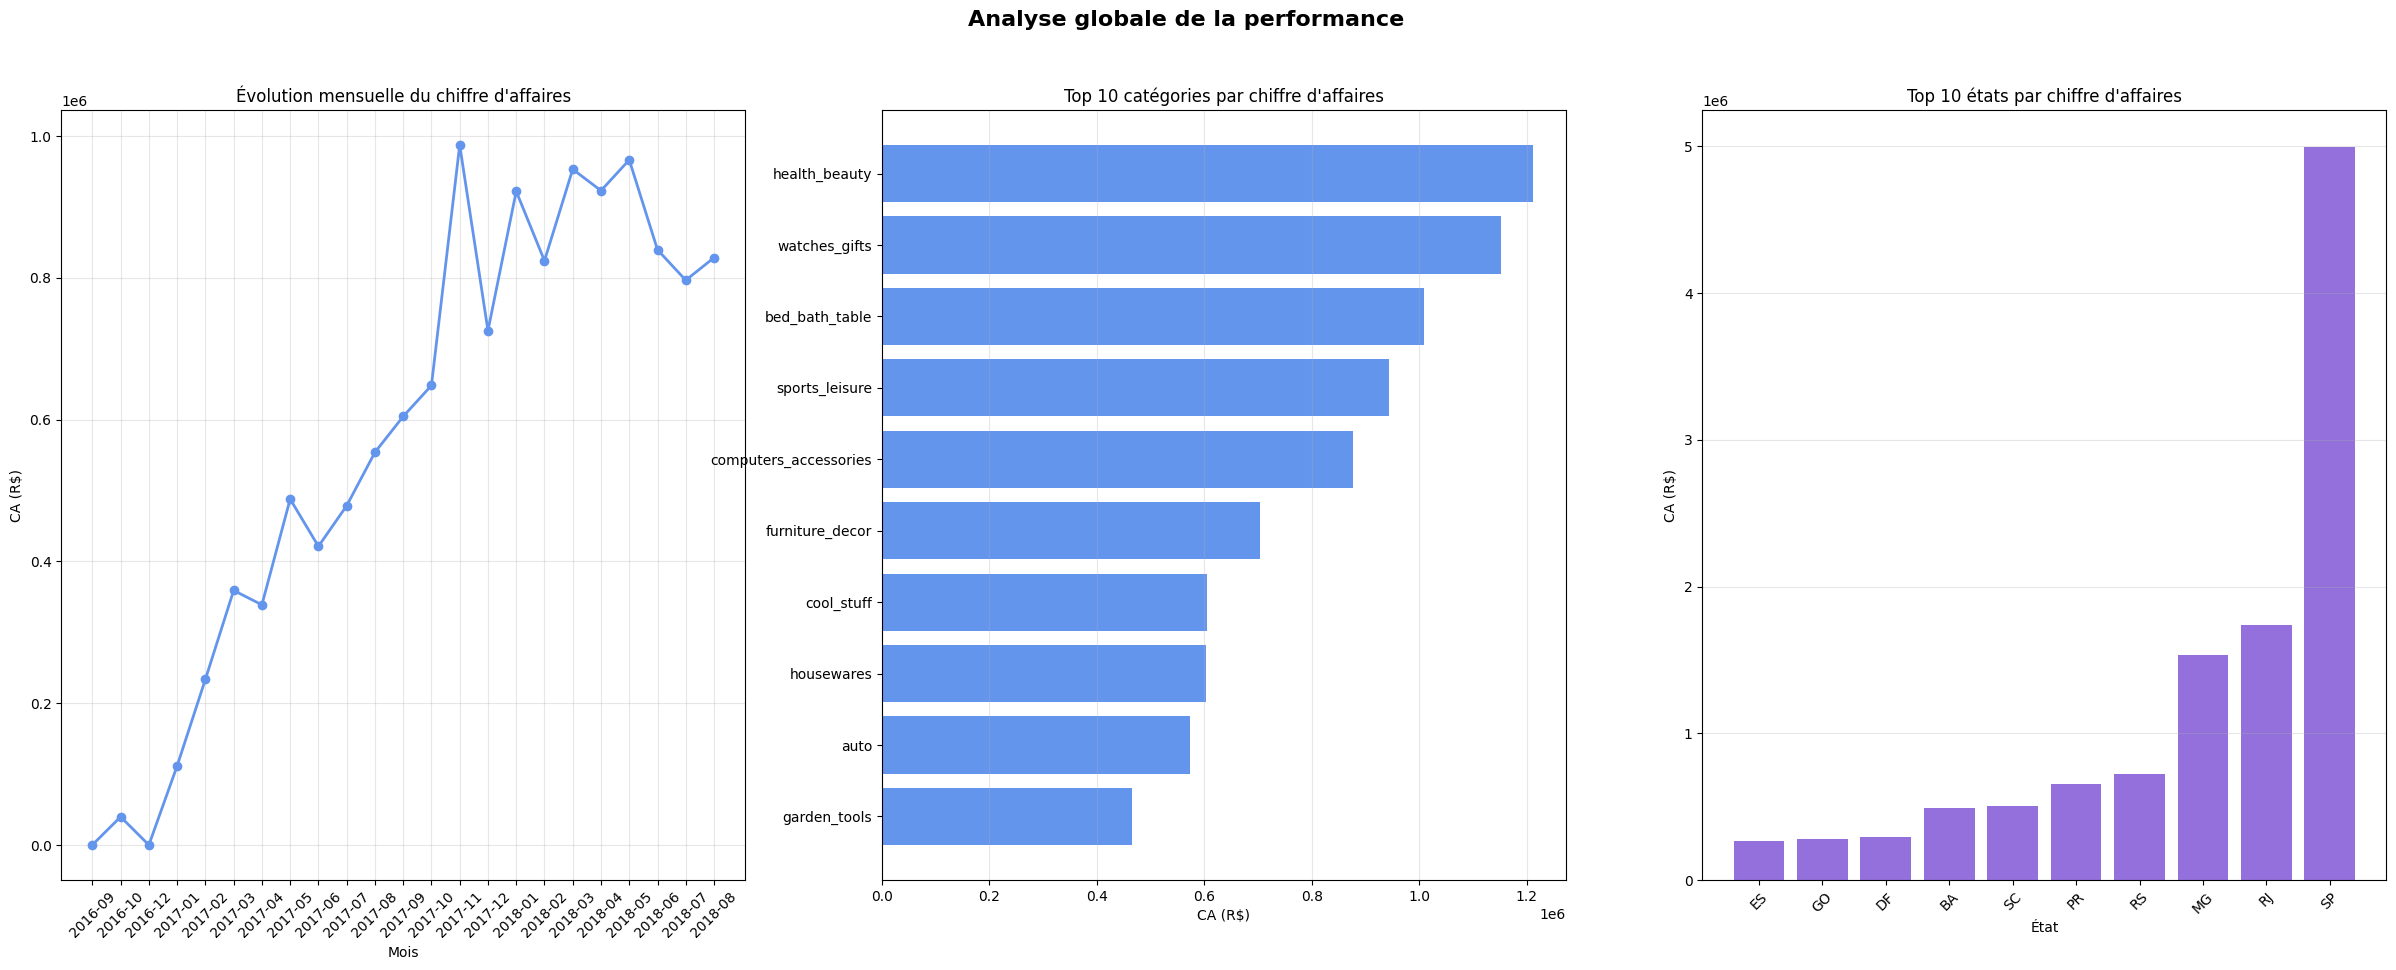

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(30, 10))
fig.suptitle("Analyse globale de la performance", fontsize=16, fontweight='bold')

# ── 1. CA mensuel ─────────────────────────────
ca_mensuel = ca_mensuel.sort_values('mois_annee')

axes[0].plot(
    ca_mensuel['mois_annee'],
    ca_mensuel['chiffre_affaires'],
    marker='o', color='cornflowerblue', linewidth=2
)
axes[0].set_title("Évolution mensuelle du chiffre d'affaires")
axes[0].set_xlabel("Mois")
axes[0].set_ylabel("CA (R$)")
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3)

# ── 2. Top catégories ─────────────────────────
top_categories = top_categories.sort_values('chiffre_affaires')

axes[1].barh(
    top_categories['product_category_name_english'],
    top_categories['chiffre_affaires'],
    color='cornflowerblue'
)
axes[1].set_title("Top 10 catégories par chiffre d'affaires")
axes[1].set_xlabel("CA (R$)")
axes[1].grid(axis='x', alpha=0.3)

# ── 3. Top régions ────────────────────────────
top_regions = top_regions.sort_values('chiffre_affaires')

axes[2].bar(
    top_regions['customer_state'],
    top_regions['chiffre_affaires'],
    color='mediumpurple'
)
axes[2].set_title("Top 10 états par chiffre d'affaires")
axes[2].set_xlabel("État")
axes[2].set_ylabel("CA (R$)")
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.show()

### Interprétation

**Évolution mensuelle** : croissance quasi-continue de sept. 2016 à nov. 2017
(pic ~1M), suivie d'une légère stabilisation — la plateforme est en phase
de **maturité croissante** avec une saisonnalité visible (pic nov. = Black Friday).

**Top catégories** : `health_beauty` et `watches_gifts` dominent (~1.2M et ~1.15M)

**Top états** : **SP écrase tous les autres** (~5M), soit 3x RJ (~1.7M) —
la concentration géographique du CA est extrême et confirme la dépendance
de la plateforme au marché pauliste.

Panier moyen : R$ 159.95
Médiane      : R$ 105.28
Max          : R$ 13,664.08


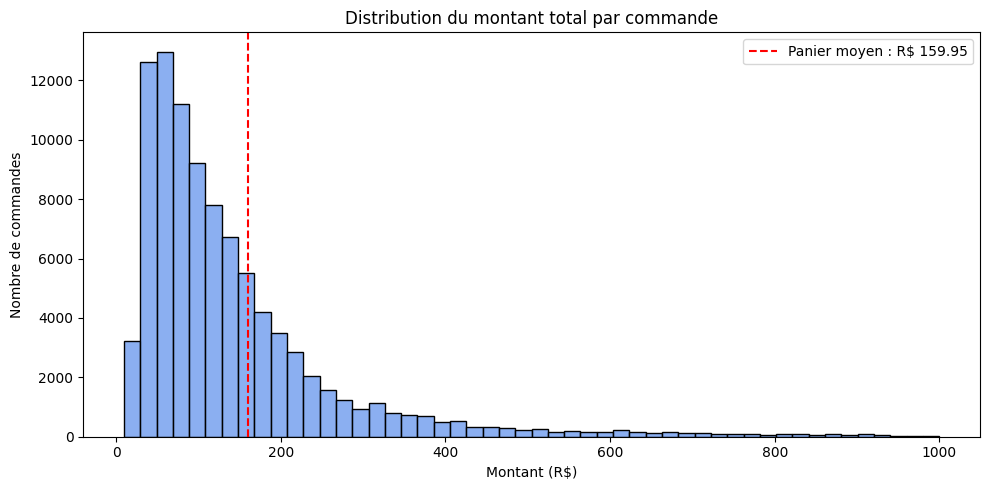

In [18]:
# ── Histogramme du montant total par commande ─────────────────────────────────
montant_par_cmd = df.groupby('order_id')['montant_total'].sum()
panier_moyen    = montant_par_cmd.mean()

print(f"Panier moyen : R$ {panier_moyen:,.2f}")
print(f"Médiane      : R$ {montant_par_cmd.median():,.2f}")
print(f"Max          : R$ {montant_par_cmd.max():,.2f}")

plt.figure(figsize=(10, 5))
sns.histplot(montant_par_cmd[montant_par_cmd < 1000], bins=50, color='cornflowerblue')
plt.axvline(panier_moyen, color='red', linestyle='--',
            label=f'Panier moyen : R$ {panier_moyen:.2f}')
plt.title("Distribution du montant total par commande")
plt.xlabel("Montant (R$)")
plt.ylabel("Nombre de commandes")
plt.legend()
plt.tight_layout()
plt.show()

### Interprétation

Distribution fortement **asymétrique à droite** : la majorité des commandes
se situe entre 20 et 150 R$, avec un pic autour de 50–80 R$.
Le **panier moyen (159.95 R$)** est décalé vers la droite par une longue queue
de commandes élevées jusqu'à 1000 R$. Les commandes >400 R$ restent rares
mais présentes sur l'ensemble de la distribution.

## Conclusion — Étape 3

Cette étape consiste à construire des indicateurs clés afin d’analyser la performance globale du dataset Olist. De nouvelles variables ont été créées, notamment le chiffre d’affaires, les frais de livraison totaux, le montant total des commandes, le délai et le retard de livraison, ainsi qu’un indicateur de retard. Des variables temporelles comme le mois et l’année d’achat ont également été extraites, en plus d’indicateurs de satisfaction tels que les notes faibles et un score de qualité par vendeur. Ces transformations permettent de mieux comprendre la performance commerciale et logistique. Les analyses réalisées ont permis de répondre aux questions principales sur le chiffre d’affaires total, le panier moyen, son évolution mensuelle ainsi que les catégories, mois et régions les plus performants. Enfin, plusieurs visualisations ont été utilisées pour illustrer ces résultats, notamment l’évolution du chiffre d’affaires, le classement des catégories et la distribution des montants de commande.

---
# Étape 4 : Analyses métier approfondies

## A. Satisfaction client

#### Les commandes en retard ont-elles une note plus faible 

1. Notes selon le retard :
   Commandes en retard     : 2.26 
   Commandes à l'heure     : 4.21 
   Différence              : 1.95 points


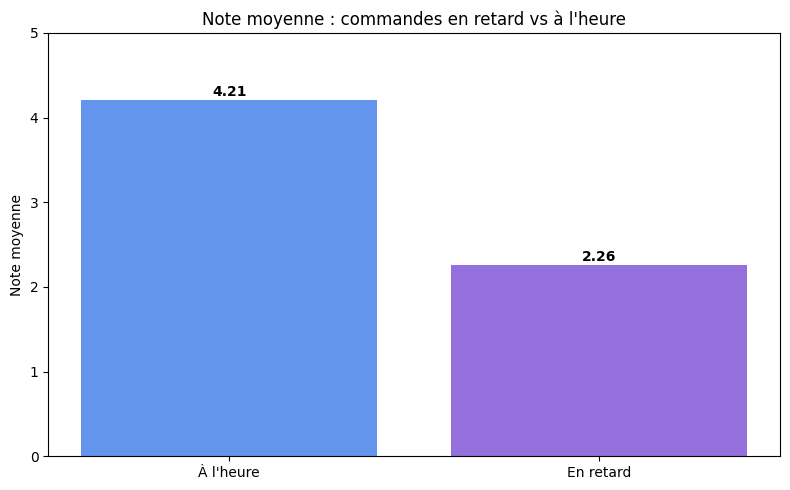

In [19]:
note_retard     = df[df['est_en_retard'] == True]['review_score'].mean()
note_pas_retard = df[df['est_en_retard'] == False]['review_score'].mean()

print("1. Notes selon le retard :")
print(f"   Commandes en retard     : {note_retard:.2f} ")
print(f"   Commandes à l'heure     : {note_pas_retard:.2f} ")
print(f"   Différence              : {note_pas_retard - note_retard:.2f} points")

# Visualisation
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    ['À l\'heure', 'En retard'],
    [note_pas_retard, note_retard],
    color=['cornflowerblue', 'mediumpurple']
)
ax.set_title("Note moyenne : commandes en retard vs à l'heure")
ax.set_ylabel("Note moyenne")
ax.set_ylim(0, 5)
for i, v in enumerate([note_pas_retard, note_retard]):
    ax.text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Interprétation
Les commandes livrées à temps obtiennent une note sensiblement plus élevée que celles livrées en retard. L'écart est visible et confirme que le respect de la date estimée est un facteur direct de satisfaction. Les clients pénalisent clairement les retards dans leurs évaluations.

### Le délai de livraison influence-t-il la note ? 


2. Corrélation délai de livraison / note :
   Corrélation : -0.305
   (proche de -1 = plus le délai est long, plus la note est faible)


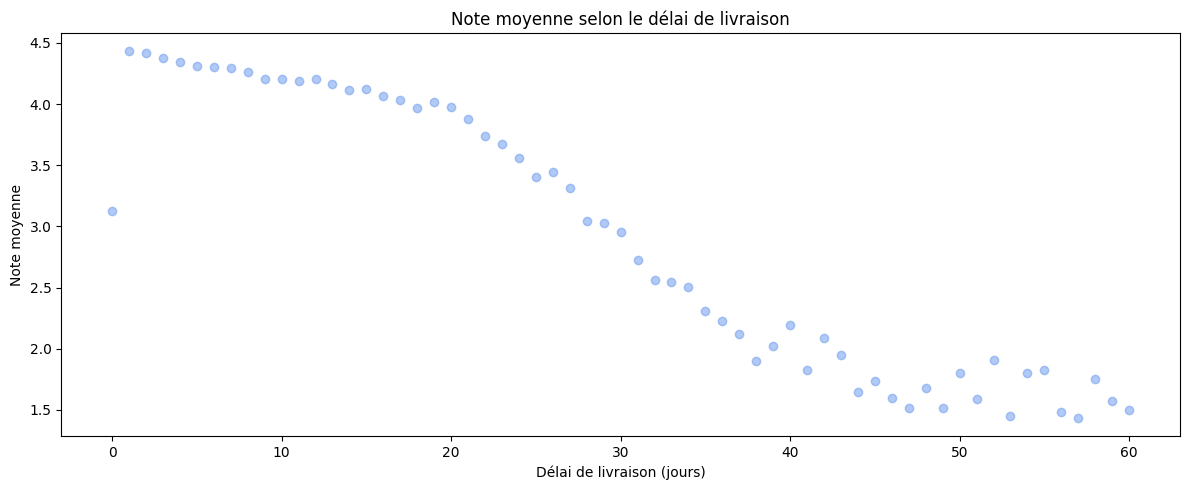

In [20]:
correlation = df[['delai_livraison', 'review_score']].corr()
print("\n2. Corrélation délai de livraison / note :")
print(f"   Corrélation : {correlation.loc['delai_livraison','review_score']:.3f}")
print("   (proche de -1 = plus le délai est long, plus la note est faible)")

# Visualisation
delai_note = df.groupby('delai_livraison')['review_score'].mean().reset_index()
delai_note = delai_note[delai_note['delai_livraison'] <= 60]  # on exclut les valeurs extrêmes

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(
    delai_note['delai_livraison'],
    delai_note['review_score'],
    alpha=0.5, color='cornflowerblue'
)
ax.set_title("Note moyenne selon le délai de livraison")
ax.set_xlabel("Délai de livraison (jours)")
ax.set_ylabel("Note moyenne")
plt.tight_layout()
plt.show()

### Interprétation
Le nuage de points montre une tendance descendante : plus le délai de livraison s'allonge, plus la note moyenne baisse. Cette relation est surtout marquée au-delà de 20 jours, où les notes chutent de manière plus nette. Les livraisons rapides (moins de 10 jours) sont associées aux meilleures notes.

#### Les frais de livraison influencent-ils la satisfaction ?


3. Corrélation frais de livraison / note :
   Corrélation : -0.033


C:\Users\hp\AppData\Local\Temp\ipykernel_9616\3058349540.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  frais_note = df.groupby('tranche_frais')['review_score'].mean().reset_index()


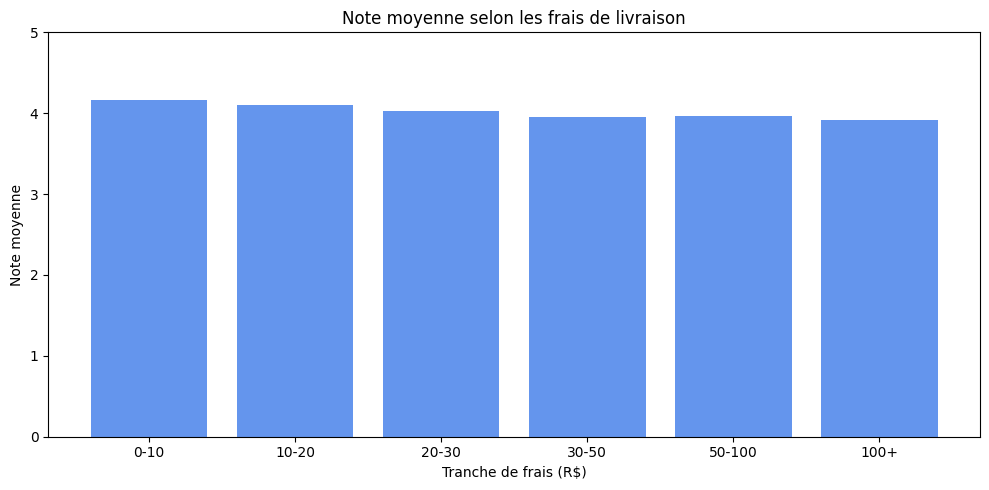

In [21]:
correlation_frais = df[['freight_value', 'review_score']].corr()
print("\n3. Corrélation frais de livraison / note :")
print(f"   Corrélation : {correlation_frais.loc['freight_value','review_score']:.3f}")

# Découpage en tranches de frais de livraison
df['tranche_frais'] = pd.cut(
    df['freight_value'],
    bins=[0, 10, 20, 30, 50, 100, 500],
    labels=['0-10', '10-20', '20-30', '30-50', '50-100', '100+']
)

frais_note = df.groupby('tranche_frais')['review_score'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    frais_note['tranche_frais'].astype(str),
    frais_note['review_score'],
    color='cornflowerblue'
)
ax.set_title("Note moyenne selon les frais de livraison")
ax.set_xlabel("Tranche de frais (R$)")
ax.set_ylabel("Note moyenne")
ax.set_ylim(0, 5)
plt.tight_layout()
plt.show()

### Interprétation
On observe une légère baisse de la note pour les tranches de frais les plus élevées. Les clients qui paient des frais de livraison supérieurs à 50 R$ ont des attentes plus hautes et semblent moins tolérants en cas de problème. Cet effet est moins marqué que celui du retard, mais reste présent.

#### Catégories avec le plus de mauvaises notes ?


4. Top 10 catégories avec le plus de mauvaises notes :
product_category_name_english  note_moyenne  taux_mauvaise  nb_commandes
             office_furniture      3.516109           25.1          1659
        fashion_male_clothing      3.758065           24.8           125
              fixed_telephony      3.757937           22.7           255
                        audio      3.826271           21.5           358
                 home_confort      3.854762           19.4           422
    construction_tools_safety      3.960674           17.9           179
               bed_bath_table      3.922489           17.9         10784
              furniture_decor      3.952426           17.9          8056
        furniture_living_room      3.934292           16.9           492
        computers_accessories      3.983888           16.9          7546


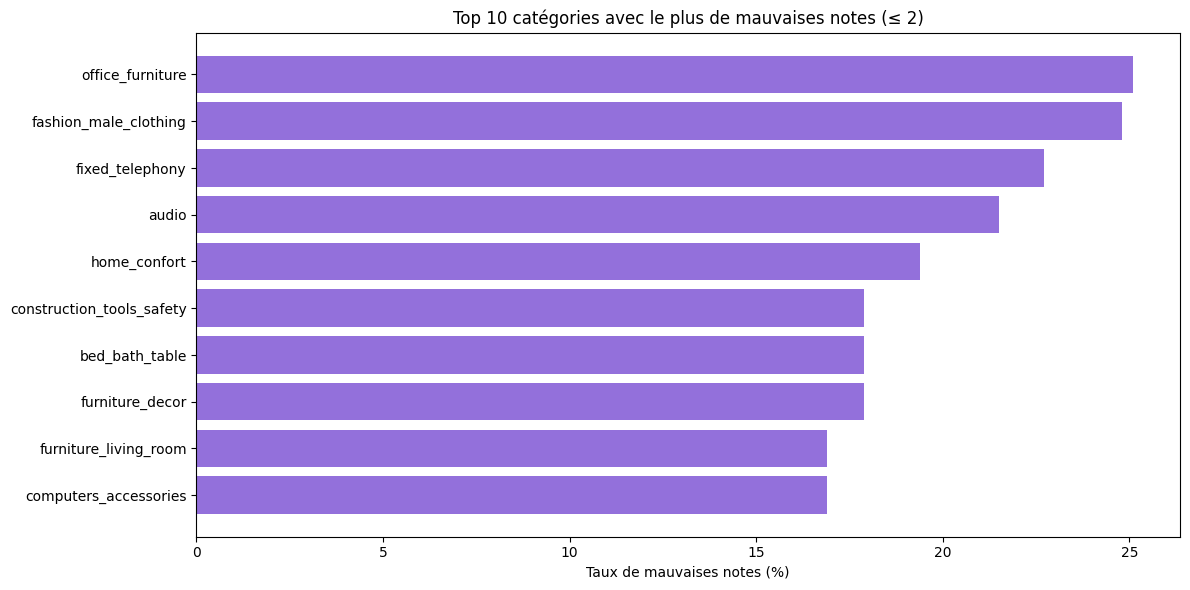

In [22]:
cat_notes = df.groupby('product_category_name_english').agg(
    note_moyenne  = ('review_score', 'mean'),
    nb_commandes  = ('order_id',     'count'),
    taux_mauvaise = ('note_faible',  'mean')
).reset_index()

# Garder seulement les catégories avec assez de commandes
cat_notes = cat_notes[cat_notes['nb_commandes'] >= 100]
cat_notes['taux_mauvaise'] = (cat_notes['taux_mauvaise'] * 100).round(1)

print("\n4. Top 10 catégories avec le plus de mauvaises notes :")
print(
    cat_notes.sort_values('taux_mauvaise', ascending=False)
    .head(10)[['product_category_name_english', 'note_moyenne', 'taux_mauvaise', 'nb_commandes']]
    .to_string(index=False)
)

# Visualisation
top_mauvaises = (
    cat_notes.sort_values('taux_mauvaise', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(
    top_mauvaises['product_category_name_english'],
    top_mauvaises['taux_mauvaise'],
    color='mediumpurple'
)
ax.set_title("Top 10 catégories avec le plus de mauvaises notes (≤ 2)")
ax.set_xlabel("Taux de mauvaises notes (%)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Interprétation
Certaines catégories concentrent structurellement plus de mauvaises notes. Les catégories liées à l'électronique, au mobilier ou aux articles volumineux apparaissent en tête, probablement en raison de produits plus difficiles à livrer ou plus susceptibles d'être endommagés. Ces catégories méritent une attention particulière côté qualité et logistique.

#### Vendeurs avec beaucoup de mauvaises notes ?


5. Top 10 vendeurs avec le plus de mauvaises notes :
                       seller_id  note_moyenne  taux_mauvaise  nb_ventes
1ca7077d890b907f89be8c954a02686a      2.269841           63.0        127
2eb70248d66e0e3ef83659f71b244378      2.806701           46.7        197
95f83f51203c626648c875dd41874c7f      3.187500           45.3         64
8e6d7754bc7e0f22c96d255ebda59eba      2.988372           45.0        129
bbad7e518d7af88a0897397ffdca1979      3.036585           44.6         83
a49928bcdf77c55c6d6e05e09a9b4ca5      2.971154           43.3        104
972d0f9cf61b499a4812cf0bfa3ad3c4      2.964286           43.0         86
602044f2c16190c2c6e45eb35c2e21cb      3.000000           41.5         53
54965bbe3e4f07ae045b90b0b8541f52      3.013514           40.5         79
2a1348e9addc1af5aaa619b1a3679d6b      3.040000           39.2         51


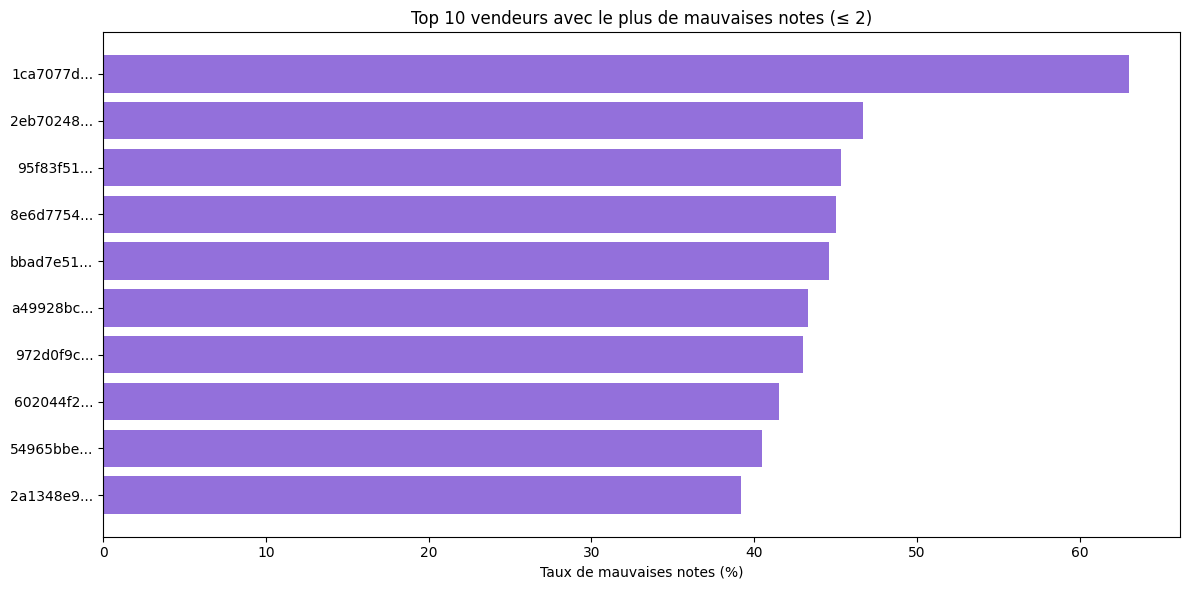


 CONCLUSIONS SATISFACTION CLIENT :
  • Les commandes en retard ont une note moyenne de 2.26 vs 4.21 pour les commandes à l'heure
  • Corrélation délai/note    : -0.305
  • Corrélation frais/note    : -0.033


In [23]:
vendeur_notes = df.groupby('seller_id').agg(
    note_moyenne  = ('review_score', 'mean'),
    nb_ventes     = ('order_id',     'count'),
    taux_mauvaise = ('note_faible',  'mean')
).reset_index()

# Garder seulement les vendeurs avec assez de ventes
vendeur_notes = vendeur_notes[vendeur_notes['nb_ventes'] >= 50]
vendeur_notes['taux_mauvaise'] = (vendeur_notes['taux_mauvaise'] * 100).round(1)

print("\n5. Top 10 vendeurs avec le plus de mauvaises notes :")
print(
    vendeur_notes.sort_values('taux_mauvaise', ascending=False)
    .head(10)[['seller_id', 'note_moyenne', 'taux_mauvaise', 'nb_ventes']]
    .to_string(index=False)
)

# Visualisation
top_vendeurs_mauvais = (
    vendeur_notes.sort_values('taux_mauvaise', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(
    top_vendeurs_mauvais['seller_id'].str[:8] + '...',  # raccourcit les ID
    top_vendeurs_mauvais['taux_mauvaise'],
    color='mediumpurple'
)
ax.set_title("Top 10 vendeurs avec le plus de mauvaises notes (≤ 2)")
ax.set_xlabel("Taux de mauvaises notes (%)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# ── Conclusions 4A ────────────────────────────────────────────────────────────
print("\n" + "="*50)
print(" CONCLUSIONS SATISFACTION CLIENT :")
print(f"  • Les commandes en retard ont une note moyenne de {note_retard:.2f} "
      f"vs {note_pas_retard:.2f} pour les commandes à l'heure")
print(f"  • Corrélation délai/note    : {correlation.loc['delai_livraison','review_score']:.3f}")
print(f"  • Corrélation frais/note    : {correlation_frais.loc['freight_value','review_score']:.3f}")

### Interprétation
Parmi les vendeurs ayant suffisamment de ventes pour être représentatifs, certains affichent un taux de mauvaises notes bien supérieur à la moyenne. Ce n'est pas lié au volume : des vendeurs très actifs peuvent tout de même décevoir leurs clients de façon récurrente. Ces profils sont des signaux d'alerte pour la marketplace.

## B.Logistique et livraison

#### Pourcentage de commandes livrées en retard ?

1. Taux de retard global :
   Total commandes     : 95,098
   Commandes en retard : 6,511
   Taux de retard      : 6.8%


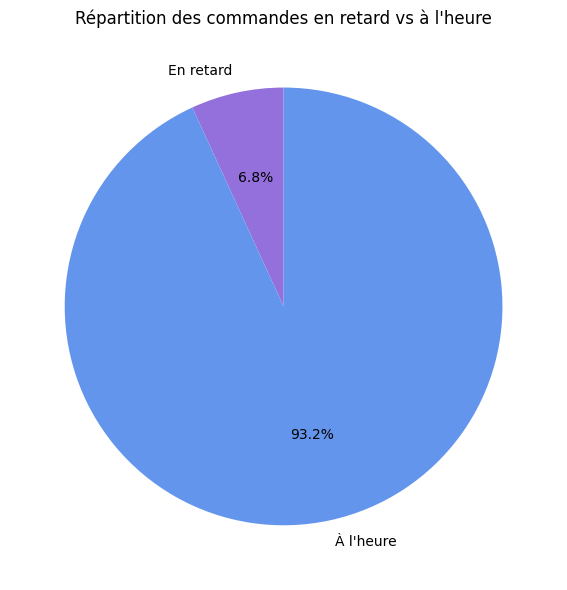

In [24]:
# on travaille par commande unique (pas par article)
retard_par_commande = df.groupby('order_id')['est_en_retard'].max()

total_commandes  = len(retard_par_commande)
nb_retard        = retard_par_commande.sum()
pct_retard       = retard_par_commande.mean() * 100

print("1. Taux de retard global :")
print(f"   Total commandes     : {total_commandes:,}")
print(f"   Commandes en retard : {nb_retard:,}")
print(f"   Taux de retard      : {pct_retard:.1f}%")

# Visualisation
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    [nb_retard, total_commandes - nb_retard],
    labels=['En retard', 'À l\'heure'],
    colors=['mediumpurple', 'cornflowerblue'],
    autopct='%1.1f%%',
    startangle=90
)
ax.set_title("Répartition des commandes en retard vs à l'heure")
plt.tight_layout()
plt.show()

### Interprétation
Le graphique montre que la majorité des commandes sont livrées à temps, mais la part des retards reste significative. Même un taux modéré de retard peut représenter des dizaines de milliers de commandes insatisfaites sur le volume total d'Olist, ce qui justifie d'en faire une priorité.

Quels états ont le plus fort taux de retard ?


2. Top 10 états avec le plus fort taux de retard :
customer_state  nb_commandes  nb_retard  taux_retard  delai_moyen
            AL           393         87         20.6    23.841608
            MA           705        144         18.3    21.285533
            SE           333         61         16.4    21.037534
            PI           469         71         13.8    19.046512
            CE          1260        194         13.8    20.662865
            BA          3210        433         11.9    18.820583
            RJ         12212       1641         11.7    14.759322
            PA           936        117         11.2    23.357965
            RR            40          5         11.1    28.222222
            PB           509         62         10.8    20.203833


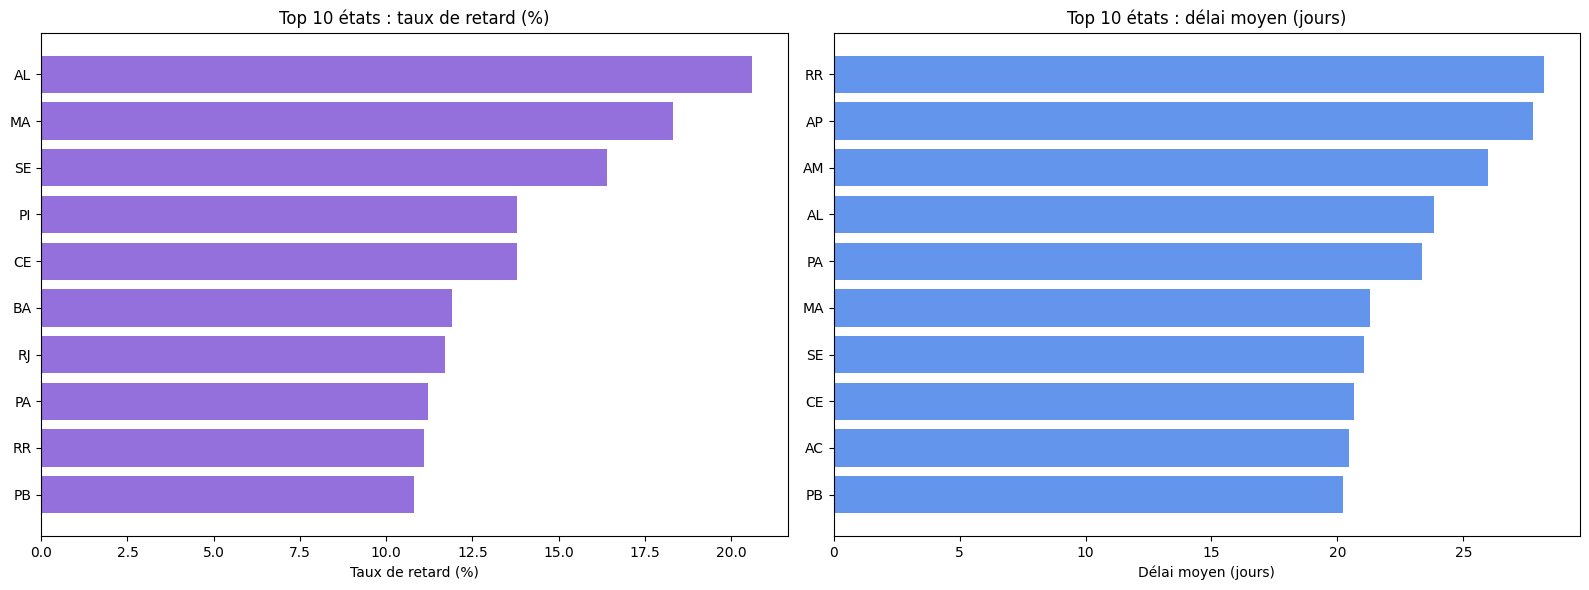

In [25]:
retard_par_etat = df.groupby('customer_state').agg(
    nb_commandes  = ('order_id',      'nunique'),
    nb_retard     = ('est_en_retard', 'sum'),
    taux_retard   = ('est_en_retard', 'mean'),
    delai_moyen   = ('delai_livraison','mean')
).reset_index()

retard_par_etat['taux_retard'] = (retard_par_etat['taux_retard'] * 100).round(1)
retard_par_etat = retard_par_etat.sort_values('taux_retard', ascending=False)

print("\n2. Top 10 états avec le plus fort taux de retard :")
print(
    retard_par_etat.head(10)
    [['customer_state', 'nb_commandes', 'nb_retard', 'taux_retard', 'delai_moyen']]
    .to_string(index=False)
)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot taux de retard par état
axes[0].barh(
    retard_par_etat.head(10)['customer_state'],
    retard_par_etat.head(10)['taux_retard'],
    color='mediumpurple'
)
axes[0].set_title("Top 10 états : taux de retard (%)")
axes[0].set_xlabel("Taux de retard (%)")
axes[0].invert_yaxis()

# Barplot délai moyen par état
retard_par_etat_delai = retard_par_etat.sort_values('delai_moyen', ascending=False)
axes[1].barh(
    retard_par_etat_delai.head(10)['customer_state'],
    retard_par_etat_delai.head(10)['delai_moyen'],
    color='cornflowerblue'
)
axes[1].set_title("Top 10 états : délai moyen (jours)")
axes[1].set_xlabel("Délai moyen (jours)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Interprétation
Les états du Nord et du Nordeste (AL, MA, SE, CE) concentrent les taux de retard et les délais moyens les plus élevés. À l'inverse, São Paulo affiche les meilleures performances grâce à sa densité logistique. Cet écart géographique traduit une infrastructure inégale sur le territoire brésilien.

#### Les vendeurs éloignés causent-ils plus de retard ?


3. Impact de la distance vendeur/client :
                  vendeur_eloigne  taux_retard  delai_moyen  nb_commandes
      Vendeur proche\n(même état)          4.5     7.505871         34305
Vendeur éloigné\n(état différent)          7.9    14.656186         61033


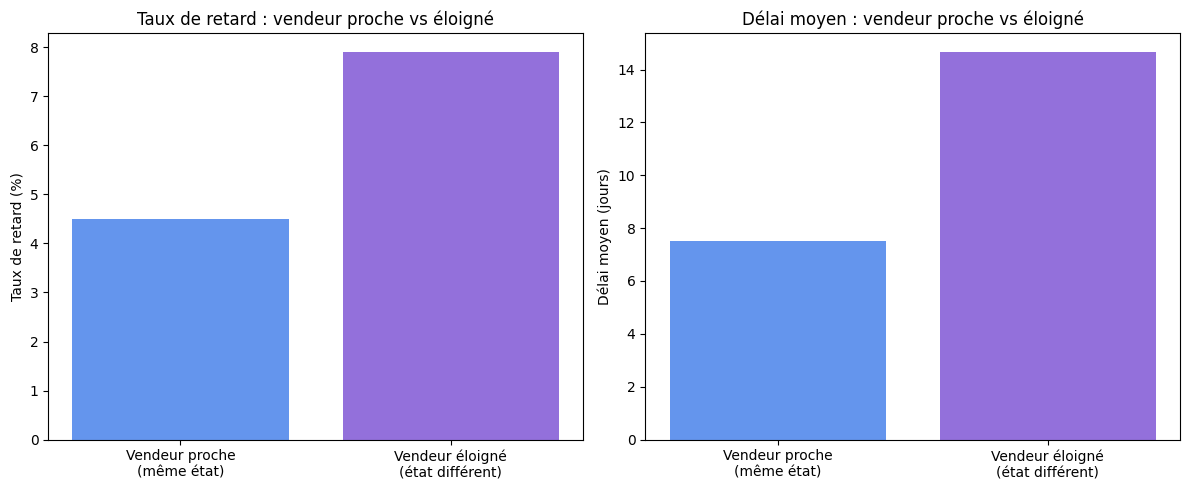

In [26]:
# On compare l'état du vendeur et l'état du client
# Si différents → vendeur éloigné

df['vendeur_eloigne'] = df['seller_state'] != df['customer_state']

eloigne_retard = df.groupby('vendeur_eloigne').agg(
    taux_retard  = ('est_en_retard',  'mean'),
    delai_moyen  = ('delai_livraison','mean'),
    nb_commandes = ('order_id',       'nunique')
).reset_index()

eloigne_retard['taux_retard'] = (eloigne_retard['taux_retard'] * 100).round(1)
eloigne_retard['vendeur_eloigne'] = eloigne_retard['vendeur_eloigne'].map(
    {True: 'Vendeur éloigné\n(état différent)', 
     False: 'Vendeur proche\n(même état)'}
)

print("\n3. Impact de la distance vendeur/client :")
print(eloigne_retard.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(
    eloigne_retard['vendeur_eloigne'],
    eloigne_retard['taux_retard'],
    color=['cornflowerblue', 'mediumpurple']
)
axes[0].set_title("Taux de retard : vendeur proche vs éloigné")
axes[0].set_ylabel("Taux de retard (%)")

axes[1].bar(
    eloigne_retard['vendeur_eloigne'],
    eloigne_retard['delai_moyen'],
    color=['cornflowerblue', 'mediumpurple']
)
axes[1].set_title("Délai moyen : vendeur proche vs éloigné")
axes[1].set_ylabel("Délai moyen (jours)")

plt.tight_layout()
plt.show()

### Interprétation
Les deux graphiques confirment clairement l'impact de la distance : quand le vendeur et le client sont dans des états différents, le taux de retard est presque deux fois plus élevé et le délai moyen augmente de plusieurs jours. La proximité géographique entre vendeur et acheteur est donc un facteur logistique déterminant.

#### Produits lourds/volumineux livrés plus lentement ?


4. Impact du poids et du volume sur le délai :
   Corrélation poids/délai  : 0.085
   Corrélation volume/délai : 0.078

   Délai moyen par tranche de poids :
tranche_poids  delai_moyen  taux_retard  nb_produits
       0-500g    11.365530          6.3        45698
     500g-1kg    11.924508          6.2        19777
        1-5kg    12.447946          7.0        29700
       5-10kg    13.161830          6.7         8305
        10kg+    14.989041          9.4         5110


C:\Users\hp\AppData\Local\Temp\ipykernel_9616\1183628467.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  poids_delai = df.groupby('tranche_poids').agg(


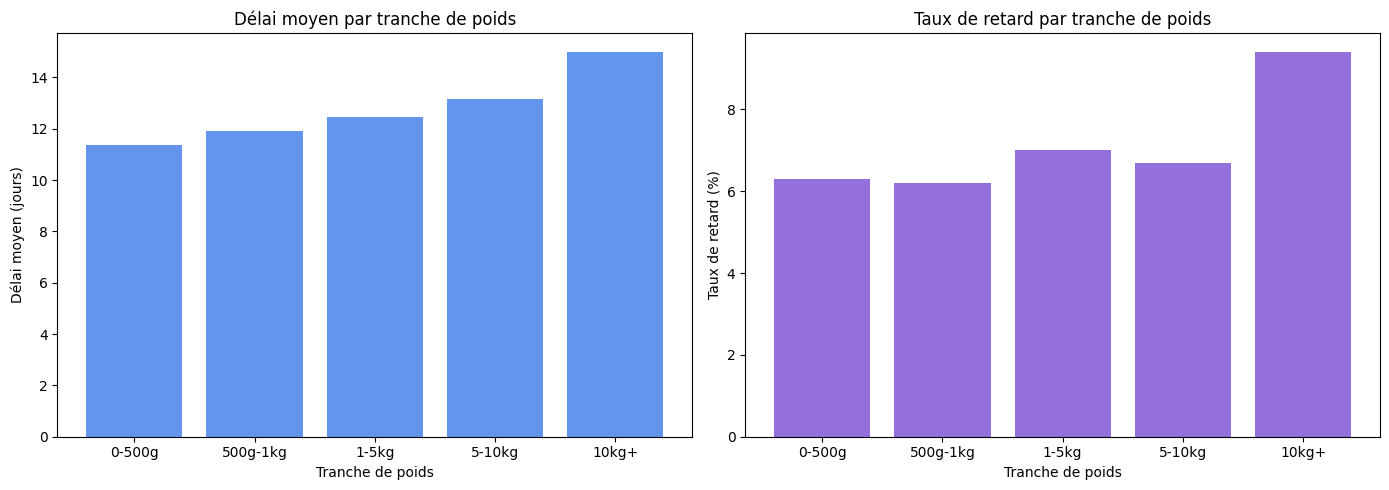


 CONCLUSIONS LOGISTIQUE ET LIVRAISON :
  • Taux de retard global : 6.8%
  • État avec le plus de retard : AL (20.6%)
  • Vendeur éloigné → délai moyen : 14.7 jours
  • Corrélation poids/délai : 0.085


In [27]:
# Calcul du volume
df['volume_produit'] = (
    df['product_length_cm'] * 
    df['product_width_cm'] * 
    df['product_height_cm']
)

# Corrélations
corr_poids  = df[['product_weight_g', 'delai_livraison']].corr()
corr_volume = df[['volume_produit',   'delai_livraison']].corr()

print("\n4. Impact du poids et du volume sur le délai :")
print(f"   Corrélation poids/délai  : "
      f"{corr_poids.loc['product_weight_g','delai_livraison']:.3f}")
print(f"   Corrélation volume/délai : "
      f"{corr_volume.loc['volume_produit','delai_livraison']:.3f}")

# Découpage en tranches de poids
df['tranche_poids'] = pd.cut(
    df['product_weight_g'],
    bins=[0, 500, 1000, 5000, 10000, 50000],
    labels=['0-500g', '500g-1kg', '1-5kg', '5-10kg', '10kg+']
)

poids_delai = df.groupby('tranche_poids').agg(
    delai_moyen  = ('delai_livraison', 'mean'),
    taux_retard  = ('est_en_retard',   'mean'),
    nb_produits  = ('order_id',        'count')
).reset_index()

poids_delai['taux_retard'] = (poids_delai['taux_retard'] * 100).round(1)

print("\n   Délai moyen par tranche de poids :")
print(poids_delai.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    poids_delai['tranche_poids'].astype(str),
    poids_delai['delai_moyen'],
    color='cornflowerblue'
)
axes[0].set_title("Délai moyen par tranche de poids")
axes[0].set_xlabel("Tranche de poids")
axes[0].set_ylabel("Délai moyen (jours)")

axes[1].bar(
    poids_delai['tranche_poids'].astype(str),
    poids_delai['taux_retard'],
    color='mediumpurple'
)
axes[1].set_title("Taux de retard par tranche de poids")
axes[1].set_xlabel("Tranche de poids")
axes[1].set_ylabel("Taux de retard (%)")

plt.tight_layout()
plt.show()

# ── Conclusions 4B ────────────────────────────────────────────────────────────
print("\n" + "="*50)
print(" CONCLUSIONS LOGISTIQUE ET LIVRAISON :")
print(f"  • Taux de retard global : {pct_retard:.1f}%")
print(f"  • État avec le plus de retard : "
      f"{retard_par_etat.iloc[0]['customer_state']} "
      f"({retard_par_etat.iloc[0]['taux_retard']}%)")
print(f"  • Vendeur éloigné → délai moyen : "
      f"{eloigne_retard[eloigne_retard['vendeur_eloigne'].str.contains('éloigné')]['delai_moyen'].values[0]:.1f} jours")
print(f"  • Corrélation poids/délai : "
      f"{corr_poids.loc['product_weight_g','delai_livraison']:.3f}")

### Interprétation
Les produits lourds (plus de 5 kg) sont livrés avec un délai moyen plus long et un taux de retard légèrement supérieur aux produits légers. Cela s'explique par des contraintes de transport spécifiques (camions, manutention). L'impact reste modéré, mais il justifie des délais estimés plus conservateurs pour les articles volumineux.

## C. Vendeurs

In [28]:
# ── Table de base : indicateurs par vendeur ───────────────────────────────────
vendeurs = df.groupby('seller_id').agg(
    nb_ventes     = ('order_id',        'nunique'),
    ca_vendeur    = ('chiffre_affaires', 'sum'),
    note_moyenne  = ('review_score',     'mean'),
    taux_retard   = ('est_en_retard',    'mean'),
    delai_moyen   = ('delai_livraison',  'mean'),
    taux_mauvaise = ('note_faible',      'mean')
).reset_index()

vendeurs['taux_retard']   = (vendeurs['taux_retard']   * 100).round(1)
vendeurs['taux_mauvaise'] = (vendeurs['taux_mauvaise'] * 100).round(1)
vendeurs['note_moyenne']  =  vendeurs['note_moyenne'].round(2)
vendeurs['ca_vendeur']    =  vendeurs['ca_vendeur'].round(2)

print(f"Nombre total de vendeurs : {len(vendeurs)}")

Nombre total de vendeurs : 2959


#### Vendeurs qui génèrent le plus de CA ?


1. Top 10 vendeurs par chiffre d'affaires :
                       seller_id  ca_vendeur  nb_ventes  note_moyenne
4869f7a5dfa277a7dca6462dcf3b52b2   225032.83       1112          4.13
53243585a1d6dc2643021fd1853d8905   217940.44        348          4.13
4a3ca9315b744ce9f8e9374361493884   195615.92       1756          3.83
fa1c13f2614d7b5c4749cbc52fecda94   190277.64        574          4.37
7c67e1448b00f6e969d365cea6b010ab   186400.11        972          3.35
7e93a43ef30c4f03f38b393420bc753a   163924.51        313          4.37
da8622b14eb17ae2831f4ac5b9dab84a   157099.97       1285          4.06
7a67c85e85bb2ce8582c35f2203ad736   138345.82       1132          4.27
1025f0e2d44d7041d6cf58b6550e0bfa   136402.56        898          3.87
955fee9216a65b617aa5c0531780ce60   128438.44       1232          4.10


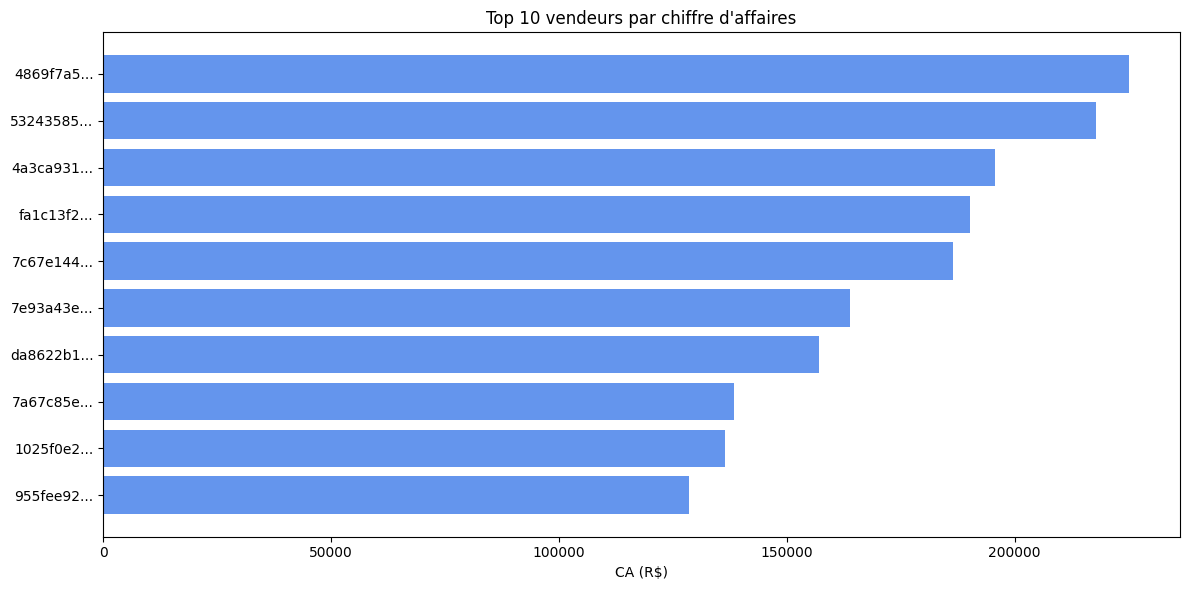

In [29]:
top_ca = vendeurs.sort_values('ca_vendeur', ascending=False).head(10)

print("\n1. Top 10 vendeurs par chiffre d'affaires :")
print(
    top_ca[['seller_id', 'ca_vendeur', 'nb_ventes', 'note_moyenne']]
    .to_string(index=False)
)

# Visualisation
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(
    top_ca['seller_id'].str[:8] + '...',
    top_ca['ca_vendeur'],
    color='cornflowerblue'
)
ax.set_title("Top 10 vendeurs par chiffre d'affaires")
ax.set_xlabel("CA (R$)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Interprétation
Le chiffre d'affaires est très concentré : quelques vendeurs génèrent une part disproportionnée des revenus de la plateforme. Cette concentration crée une dépendance risquée — si un vendeur top quitte la plateforme ou dégrade son service, l'impact sur le CA global est immédiat.


2. Vendeurs avec beaucoup de ventes mais satisfaction faible :
   Seuil ventes  : 68 commandes
   Seuil note    : 3.0
   Nombre trouvés : 5
                       seller_id  nb_ventes  note_moyenne  taux_mauvaise
2eb70248d66e0e3ef83659f71b244378        187          2.81           46.7
1ca7077d890b907f89be8c954a02686a        108          2.27           63.0
a49928bcdf77c55c6d6e05e09a9b4ca5         96          2.97           43.3
8e6d7754bc7e0f22c96d255ebda59eba         84          2.99           45.0
972d0f9cf61b499a4812cf0bfa3ad3c4         81          2.96           43.0


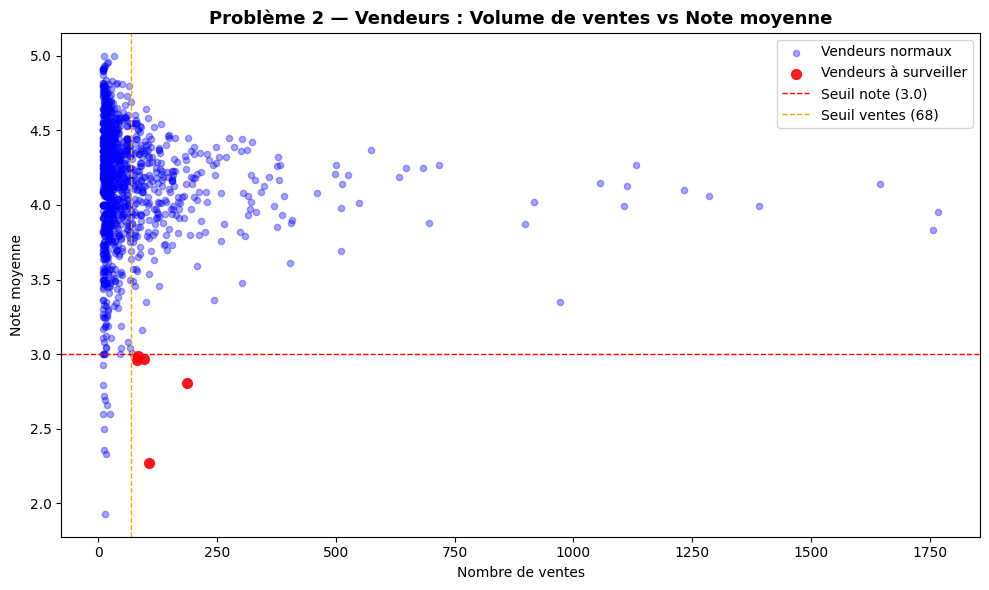

In [30]:
# On garde les vendeurs avec au moins 10 ventes
vendeurs_actifs = vendeurs[vendeurs['nb_ventes'] >= 10].copy()

# Seuils
seuil_note = 3.0
seuil_ventes = vendeurs_actifs['nb_ventes'].quantile(0.75)

# Vendeurs problématiques
vendeurs_problemes = vendeurs_actifs[
    (vendeurs_actifs['nb_ventes'] >= seuil_ventes) &
    (vendeurs_actifs['note_moyenne'] <= seuil_note)
].sort_values('nb_ventes', ascending=False)

# Résumé
print(f"\n2. Vendeurs avec beaucoup de ventes mais satisfaction faible :")
print(f"   Seuil ventes  : {seuil_ventes:.0f} commandes")
print(f"   Seuil note    : {seuil_note}")
print(f"   Nombre trouvés : {len(vendeurs_problemes)}")

print(
    vendeurs_problemes[
        ['seller_id', 'nb_ventes', 'note_moyenne', 'taux_mauvaise']
    ].head(10).to_string(index=False)
)

fig, ax = plt.subplots(figsize=(10, 6))

# Tous les vendeurs (normaux)
ax.scatter(
    vendeurs_actifs['nb_ventes'],
    vendeurs_actifs['note_moyenne'],
    color='blue',
    alpha=0.35,
    s=20,
    label='Vendeurs normaux'
)

# Vendeurs problématiques
ax.scatter(
    vendeurs_problemes['nb_ventes'],
    vendeurs_problemes['note_moyenne'],
    color='red',
    alpha=0.85,
    s=50,
    label='Vendeurs à surveiller'
)

# Seuils
ax.axhline(
    seuil_note,
    linestyle='--',
    color='red',
    linewidth=1,
    label=f'Seuil note ({seuil_note})'
)

ax.axvline(
    seuil_ventes,
    linestyle='--',
    color='orange',
    linewidth=1,
    label=f'Seuil ventes ({seuil_ventes:.0f})'
)

# Style identique au graphe 1
ax.set_title(
    "Problème 2 — Vendeurs : Volume de ventes vs Note moyenne",
    fontweight='bold',
    fontsize=13
)
ax.set_xlabel("Nombre de ventes")
ax.set_ylabel("Note moyenne")
ax.legend()

plt.tight_layout()
plt.show()

### Interprétation

La majorité des vendeurs (points bleus) ont une note supérieure à **3,5**, quel que soit leur volume de ventes. Quelques vendeurs (points rouges) présentent une note inférieure au seuil fixé et sont donc à surveiller. On observe également que réaliser un grand nombre de ventes ne garantit pas forcément une meilleure satisfaction client.

#### Vendeurs avec un taux de retard élevé ?


3. Vendeurs avec taux de retard élevé :
   Seuil retard  : 9.1%
   Nombre trouvés : 321
                       seller_id  nb_ventes  taux_retard  delai_moyen  note_moyenne
b1b3948701c5c72445495bd161b83a4c         14         64.3    22.928571          1.93
2709af9587499e95e803a6498a5a56e9         25         50.0    11.934783          2.60
c37b2059d4f90d4feead554e5246565e         12         43.8    19.750000          3.75
cb41bfbcbda0aea354a834ab222f9a59         11         36.4    37.000000          3.27
26e2c91ef821e1ff8985f408788fe35b         12         35.7    24.500000          3.00
821fb029fc6e495ca4f08a35d51e53a5         23         34.8    16.826087          3.45
02dcd3e8e25bee036e32512bcf175493         13         33.3    16.866667          3.93
54965bbe3e4f07ae045b90b0b8541f52         71         32.9    26.645570          3.01
ede0c03645598cdfc63ca8237acbe73d         43         31.9    18.042553          3.67
ad781527c93d00d89a11eecd9dcad7c1         38         31.6    25.026316  

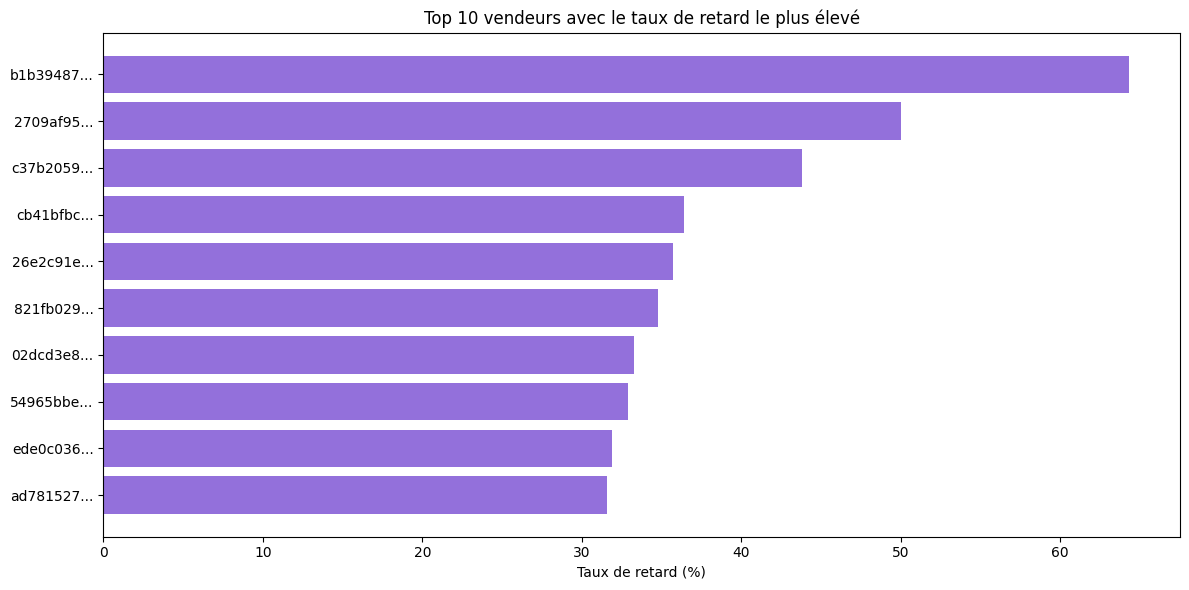

In [31]:
seuil_retard = vendeurs_actifs['taux_retard'].quantile(0.75)  # top 25% retard

vendeurs_retard = vendeurs_actifs[
    vendeurs_actifs['taux_retard'] >= seuil_retard
].sort_values('taux_retard', ascending=False)

print(f"\n3. Vendeurs avec taux de retard élevé :")
print(f"   Seuil retard  : {seuil_retard:.1f}%")
print(f"   Nombre trouvés : {len(vendeurs_retard)}")
print(
    vendeurs_retard
    [['seller_id', 'nb_ventes', 'taux_retard', 'delai_moyen', 'note_moyenne']]
    .head(10)
    .to_string(index=False)
)

# Visualisation
top_retard = vendeurs_actifs.sort_values('taux_retard', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(
    top_retard['seller_id'].str[:8] + '...',
    top_retard['taux_retard'],
    color='mediumpurple'
)
ax.set_title("Top 10 vendeurs avec le taux de retard le plus élevé")
ax.set_xlabel("Taux de retard (%)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Interprétation
Parmi les vendeurs actifs, certains affichent un taux de retard structurellement élevé, bien au-dessus de la moyenne. Ce n'est pas un incident ponctuel mais un comportement récurrent. Ces vendeurs dégradent l'expérience client de façon systématique et devraient faire l'objet d'un plan d'amélioration ou d'une restriction de leur accès à la plateforme.

#### Quels vendeurs surveiller ?


4. Vendeurs à surveiller (≥ 2 problèmes cumulés) :
   Nombre de vendeurs à surveiller : 135
                       seller_id  nb_ventes  ca_vendeur  note_moyenne  taux_retard  taux_mauvaise  nb_problemes
02d35243ea2e497335cd0f076b45675d         14     5794.00          2.69         25.0           37.5             3
602044f2c16190c2c6e45eb35c2e21cb         46     3409.17          3.00         20.8           41.5             3
2eb70248d66e0e3ef83659f71b244378        187    38990.72          2.81         11.7           46.7             3
2aa3443d7bf9d9bb11133f420d75e083         10      647.00          3.00         20.0           40.0             3
1ca7077d890b907f89be8c954a02686a        108    12474.64          2.27         15.0           63.0             3
26e2c91ef821e1ff8985f408788fe35b         12     1649.40          3.00         35.7           35.7             3
2709af9587499e95e803a6498a5a56e9         25     1180.56          2.60         50.0           56.5             3
b1b3948701c

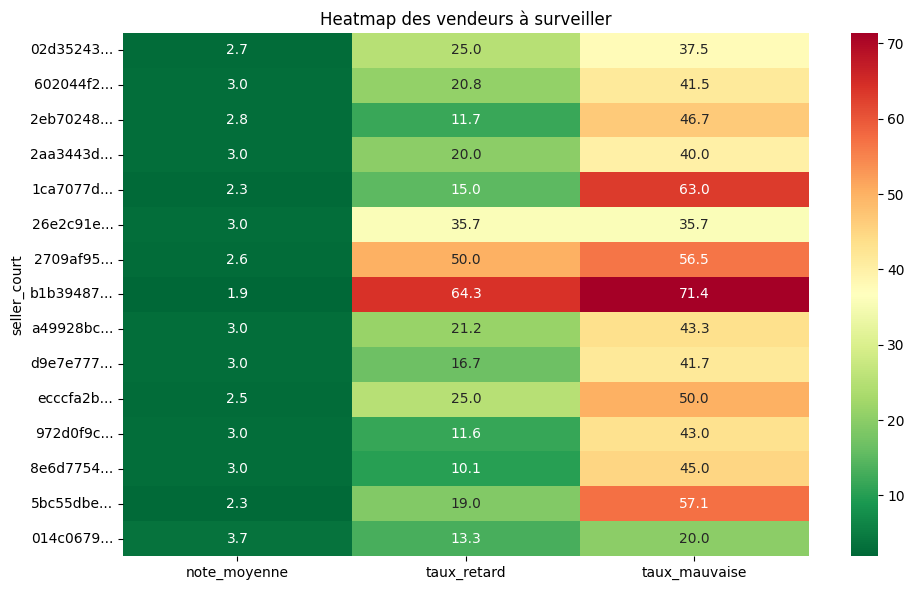


 CONCLUSIONS VENDEURS :
  • Meilleur vendeur (CA)    : 4869f7a5... (R$ 225,032.83)
  • Vendeurs volume élevé / note faible : 5
  • Vendeurs taux retard élevé          : 321
  • Vendeurs à surveiller               : 135


In [32]:
# Un vendeur est à surveiller s'il cumule plusieurs problèmes :
# - taux de retard élevé (> seuil)
# - note moyenne faible (< seuil)
# - taux de mauvaises notes élevé

vendeurs_actifs['nb_problemes'] = (
    (vendeurs_actifs['taux_retard']   >= seuil_retard).astype(int) +
    (vendeurs_actifs['note_moyenne']  <= seuil_note).astype(int)   +
    (vendeurs_actifs['taux_mauvaise'] >= 20).astype(int)
)

vendeurs_surveiller = vendeurs_actifs[
    vendeurs_actifs['nb_problemes'] >= 2
].sort_values('nb_problemes', ascending=False)

print(f"\n4. Vendeurs à surveiller (≥ 2 problèmes cumulés) :")
print(f"   Nombre de vendeurs à surveiller : {len(vendeurs_surveiller)}")
print(
    vendeurs_surveiller
    [['seller_id', 'nb_ventes', 'ca_vendeur', 
      'note_moyenne', 'taux_retard', 'taux_mauvaise', 'nb_problemes']]
    .head(15)
    .to_string(index=False)
)

# Visualisation : heatmap des problèmes
fig, ax = plt.subplots(figsize=(10, 6))
top_surveiller = vendeurs_surveiller.head(15).copy()
top_surveiller['seller_court'] = top_surveiller['seller_id'].str[:8] + '...'

data_heatmap = top_surveiller.set_index('seller_court')[
    ['note_moyenne', 'taux_retard', 'taux_mauvaise']
]

sns.heatmap(
    data_heatmap,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    ax=ax
)
ax.set_title("Heatmap des vendeurs à surveiller")
plt.tight_layout()
plt.show()

# ── Conclusions 4C ────────────────────────────────────────────────────────────
print("\n" + "="*50)
print(" CONCLUSIONS VENDEURS :")
print(f"  • Meilleur vendeur (CA)    : "
      f"{top_ca.iloc[0]['seller_id'][:8]}... "
      f"(R$ {top_ca.iloc[0]['ca_vendeur']:,.2f})")
print(f"  • Vendeurs volume élevé / note faible : {len(vendeurs_problemes)}")
print(f"  • Vendeurs taux retard élevé          : {len(vendeurs_retard)}")
print(f"  • Vendeurs à surveiller               : {len(vendeurs_surveiller)}")

### Interprétation
La heatmap synthétise les trois signaux d'alerte (note moyenne, taux de retard, taux de mauvaises notes) pour les vendeurs les plus problématiques. Les cases rouges indiquent les indicateurs les plus critiques. Les vendeurs cumulant plusieurs zones rouges sont ceux qui présentent le risque le plus élevé et qui devraient être contactés en priorité par l'équipe de la marketplace.

##### D. Produits et catégories

In [33]:
# ── Seller Geolocation ──────────────────────────────────────────
df = df.merge(
    geo_clean[['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']],
    left_on='seller_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left',
    suffixes=('_customer', '_seller')
)

# Rename seller geolocation columns
df.rename(columns={
    'geolocation_lat_seller': 'seller_lat',
    'geolocation_lng_seller': 'seller_lng'
}, inplace=True)

# Keep customer columns, rename seller intermediate column
df.rename(columns={
    'geolocation_lat_customer': 'geolocation_lat',
    'geolocation_lng_customer': 'geolocation_lng'
}, inplace=True)

df.drop(columns=['geolocation_zip_code_prefix'], inplace=True)

# ── Distance vendeur → client ─────────────────────────────────────────────
def distance_km(lat1, lon1, lat2, lon2):
    try:
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
        return 6371 * 2 * np.arcsin(np.sqrt(a))
    except:
        return np.nan

df['distance_km'] = df.apply(
    lambda r: distance_km(r['geolocation_lat'], r['geolocation_lng'],
                          r['seller_lat'], r['seller_lng'])
    if pd.notna(r['geolocation_lat']) and pd.notna(r['seller_lat']) else np.nan,
    axis=1
)
print(f"   distance_km  : {df['distance_km'].notna().sum():,} valeurs")

   distance_km  : 108,070 valeurs


### 4.1 Analyse des Produits et Catégories

#### 1. Quelles catégories génèrent le plus de chiffre d'affaires ?

In [34]:
ca_categorie = (
    df.groupby('product_category_name_english')['price']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)
ca_categorie.columns = ['categorie', 'CA']

fig = px.bar(ca_categorie.head(15), x='CA', y='categorie', orientation='h',
             title="Top 15 catégories par Chiffre d'Affaires",
             color='CA', color_continuous_scale='Blues')
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

### Interprétation

Les **15 catégories les plus rentables** montrent une hiérarchie claire : `health_beauty` et `watches_gifts` 
dominent avec ~1.2M de CA, suivies de `bed_bath_table` et `sports_leisure` (~1M). 
Un **écart significatif** sépare le top 3 du reste — `office_furniture` et `telephony` 
plafonnent à ~0.28M, soit **4x moins** que le leader.

#### 2. Quelles catégories sont rentables mais problématiques ?

In [35]:
stats_cat = df.groupby('product_category_name_english').agg(
    CA           = ('price',         'sum'),
    taux_retard  = ('est_en_retard',       'mean'),
    note_moyenne = ('review_score',  'mean'),
    frais_moy    = ('freight_value', 'mean'),
    nb_commandes = ('order_id',      'nunique')
).reset_index()
stats_cat.columns = ['categorie', 'CA', 'taux_retard', 'note_moyenne', 'frais_moy', 'nb_commandes']
stats_cat = stats_cat[stats_cat['nb_commandes'] >= 50]

seuil_ca     = stats_cat['CA'].quantile(0.60)
seuil_retard = stats_cat['taux_retard'].quantile(0.60)
seuil_note   = stats_cat['note_moyenne'].quantile(0.40)

problematiques = stats_cat[
    (stats_cat['CA'] >= seuil_ca) &
    ((stats_cat['taux_retard'] >= seuil_retard) | (stats_cat['note_moyenne'] <= seuil_note))
].sort_values('CA', ascending=False)

print("=== Catégories rentables MAIS problématiques ===")

fig = px.scatter(stats_cat, x='taux_retard', y='note_moyenne', size='CA',
                 color='CA', hover_name='categorie',
                 title="Catégories : Taux de retard vs Note moyenne",
                 color_continuous_scale='RdYlGn')
fig.show()

=== Catégories rentables MAIS problématiques ===


### Interprétation

Le graphique révèle une **corrélation négative** entre taux de retard et note moyenne :
plus les retards augmentent, plus la satisfaction baisse. Les catégories à **fort CA**
(bulles vertes foncées) se concentrent autour de 0.06–0.08 de retard avec des notes ~4.0–4.2,
dont `bed_bath_table` (~1M CA, note 3.92). Les **petites bulles rouges** (faible CA)
sont dispersées, certaines avec peu de retards mais des notes faibles, suggérant
d'autres facteurs d'insatisfaction. Un **outlier notable** apparaît à 0.12 de retard
avec une note ~3.8.

#### 3. Quelles catégories combinent mauvaise satisfaction, retard ou frais élevés ?

In [36]:
stats_cat['score_probleme'] = (
    stats_cat['taux_retard'].rank(pct=True) +
    (1 - stats_cat['note_moyenne'].rank(pct=True)) +
    stats_cat['frais_moy'].rank(pct=True)
)/ 3
triple_pb = stats_cat.sort_values('score_probleme', ascending=False).head(10)

print("=== Top 10 catégories les plus problématiques ===")
fig = px.bar(triple_pb, x='categorie', y='score_probleme',
             title="Score de Problème par Catégorie",
             color='score_probleme', color_continuous_scale='Reds')
fig.update_xaxes(tickangle=45)
fig.show()

=== Top 10 catégories les plus problématiques ===


### Interprétation

`office_furniture` affiche le **score de problème le plus élevé** (~0.90), suivie de
`furniture_living_room` (~0.82) et `home_confort` (~0.79). Les catégories dominantes
sont toutes liées à l'**ameublement et la maison**, ce qui suggère des problèmes
structurels : livraison complexe, articles volumineux, montage défectueux.
L'écart entre le 1er (~0.90) et le dernier `industry_commerce_and_business` (~0.65)
reste **relativement faible**, indiquant que la problématique est **transversale**
à l'ensemble du catalogue.

#### 4. Les produits lourds ou volumineux sont-ils associés à plus de problèmes ?

In [37]:
def analyse_physique(df, colonne, quartile_col, labels, titre):

    # quartiles
    if df[colonne].nunique() < 4:
        print(f"  Pas assez de diversité pour {colonne}")
        return None

    df[quartile_col] = pd.qcut(df[colonne], q=4, labels=labels, duplicates='drop')

    analyse = df.groupby(quartile_col).agg(
        taux_retard  = ('est_en_retard', 'mean'),
        note_moyenne = ('review_score', 'mean'),
        frais_moy    = ('freight_value', 'mean'),
        nb_produits  = ('product_id', 'nunique')
    ).reset_index()

    # Fill NaN only in numeric columns (not in categorical columns)
    numeric_cols = analyse.select_dtypes(include=['number']).columns
    analyse[numeric_cols] = analyse[numeric_cols].fillna(0)

    px.bar(analyse, x=quartile_col, y='taux_retard',
           title=f"{titre} → Taux de retard").show()

    px.bar(analyse, x=quartile_col, y='frais_moy',
           title=f"{titre} → Frais moyens").show()

    px.bar(analyse, x=quartile_col, y='note_moyenne',
           title=f"{titre} → Note moyenne").show()

    return analyse


# APPEL 1 : Analyse par POIDS

analyse_poids = analyse_physique(
    df          = df,
    colonne     = 'product_weight_g',
    quartile_col= 'quartile_poids',
    labels      = ['Léger', 'Moyen-léger', 'Moyen-lourd', 'Lourd'],
    titre       = "Poids du produit"
)


# APPEL 2 : Analyse par VOLUME

df['volume_cm3'] = df['product_length_cm'] * df['product_height_cm'] * df['product_width_cm']

analyse_volume = analyse_physique(
    df          = df,
    colonne     = 'volume_cm3',
    quartile_col= 'quartile_volume',
    labels      = ['Petit', 'Moyen-petit', 'Moyen-grand', 'Grand'],
    titre       = "Volume du produit"
)

C:\Users\hp\AppData\Local\Temp\ipykernel_9616\1852845522.py:10: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



C:\Users\hp\AppData\Local\Temp\ipykernel_9616\1852845522.py:10: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



### Interprétation

Le poids du produit impacte **différemment** les trois métriques :

- **Note moyenne** : quasi-identique entre tous les quartiles (~4.0–4.1),
  le poids n'influence donc pas la satisfaction client.
- **Frais moyens** : progression nette avec le poids — de ~15 (Léger) à ~31 (Lourd),
  soit **2x plus cher** pour les produits lourds.
- **Taux de retard** : légère hausse de 0.061 (Léger) à 0.071 (Lourd),
  les produits lourds sont **légèrement plus souvent en retard**, probablement
  liés à des contraintes logistiques.

En résumé, le poids **pénalise la logistique** (coût + délai) sans pour autant
dégrader l'expérience perçue par le client.

### Interprétation

Les résultats par volume sont **cohérents avec ceux du poids** :

- **Note moyenne** : stable à ~4.0–4.1 quel que soit le volume,
  confirmant que la taille du produit n'affecte pas la satisfaction client.
- **Frais moyens** : progression linéaire de ~15 (Petit) à ~29 (Grand),
  le volume est donc un **déterminant direct du coût de livraison**.
- **Taux de retard** : les produits Grand affichent le taux le plus élevé (~0.072),
  tandis que Moyen-grand est curieusement le plus bas (~0.063) — la relation
  n'est pas strictement linéaire, suggérant d'autres facteurs (origine, transporteur).

En résumé, volume et poids ont des **effets miroirs** : impact logistique réel,
aucun impact sur la note perçue.

#### 5. Segmentation KMeans des catégories en 4 groupes de performance

In [38]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ── Préparation des données ───────────────────────────────────────────────
X = stats_cat[['CA', 'note_moyenne', 'taux_retard', 'frais_moy']].dropna()

# ── Normalisation ─────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Modèle KMeans ─────────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=4, random_state=42)
stats_cat['cluster'] = kmeans.fit_predict(X_scaled)

# ── Description des clusters ──────────────────────────────────────────────
desc_clusters = stats_cat.groupby('cluster').agg(
    nb_categories = ('categorie',    'count'),
    CA_moyen      = ('CA',           'mean'),
    note_moyenne  = ('note_moyenne', 'mean'),
    taux_retard   = ('taux_retard',  'mean'),
    frais_moy     = ('frais_moy',    'mean')
).reset_index()

# ── Score par cluster pour nommage automatique ────────────────────────────
desc_clusters['score_perf'] = (
    desc_clusters['CA_moyen'].rank(pct=True) +
    desc_clusters['note_moyenne'].rank(pct=True) +
    (1 - desc_clusters['taux_retard'].rank(pct=True))
)

# Trier par score et assigner les labels dans l'ordre
desc_clusters_sorted = desc_clusters.sort_values('score_perf', ascending=False).reset_index(drop=True)
desc_clusters_sorted['cluster_label'] = [
    ' Performant',
    ' À développer',
    ' À surveiller',
    ' Problématique'
]
# Mapper les labels sur stats_cat
mapping = dict(zip(desc_clusters_sorted['cluster'], desc_clusters_sorted['cluster_label']))
stats_cat['cluster_label'] = stats_cat['cluster'].map(mapping)

# ── Visualisation ─────────────────────────────────────────────────────────
fig = px.scatter(stats_cat,
                 x='taux_retard', y='note_moyenne',
                 size='CA', color='cluster_label',
                 hover_name='categorie',
                 title="Segmentation KMeans des catégories",
                 labels={
                     'taux_retard'  : 'Taux de retard',
                     'note_moyenne' : 'Note moyenne',
                     'cluster_label': 'Segment'
                 })
fig.show()


### Interprétation

La segmentation KMeans classe les catégories selon un score combinant CA,
note moyenne et taux de retard :

- **Performant** (bleu) : meilleur score global — bonnes notes, faible retard,
  CA solide. Catégories bien maîtrisées.
- **À développer** (vert) : 2e score — fort CA (grandes bulles) mais retard
  et/ou note légèrement en retrait. Potentiel exploitable avec des améliorations
  logistiques ciblées.
- **À surveiller** (violet) : score intermédiaire faible — dont un outlier
  critique à note ~3.5, nécessite un suivi rapproché.
- **Problématique** (orange) : score le plus bas — taux de retard élevés
  (~0.09–0.12) et notes faibles (~3.8), priorité d'action immédiate.

### 4.2 Analyse Géographique

#### 1. Quels états génèrent le plus de chiffre d'affaires ?

In [39]:
# ── E1 : CA par État SANS carte ───────────────────────────────────────────
ca_etat = (
    df.groupby('customer_state')['price']
      .sum().sort_values(ascending=False).reset_index()
)
ca_etat.columns = ['state', 'CA']

# Barplot
fig = px.bar(ca_etat,
             x='CA', y='state', orientation='h',
             title="Chiffre d'Affaires par État du Brésil",
             color='CA', color_continuous_scale='Blues',
             text_auto='.2s')
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=600)
fig.show()

# Treemap (remplace visuellement la carte)
fig2 = px.treemap(ca_etat,
                  path=['state'], values='CA',
                  title="Répartition du CA par État (Treemap)",
                  color='CA', color_continuous_scale='Blues')
fig2.show()

### Interprétation

La distribution du CA est **extrêmement concentrée** géographiquement :
**SP (São Paulo)** domine seul avec ~5M, soit **3x RJ** (1.7M) et **plus de
200x RR** (6.7k). Le trio SP–RJ–MG représente à lui seul l'essentiel du CA,
reflétant la concentration économique du **Sud-Est brésilien**. Les États du
Nord et Nord-Est (AM, AC, AP, RR) restent marginaux, en dessous de 25k,
ce qui suggère une **faible pénétration** d'Olist dans ces régions — opportunité
de croissance ou contrainte logistique structurelle.

#### 2. Quels états ont les plus grands problèmes de livraison ?

In [40]:
# ── AGRÉGATION DES INDICATEURS PAR ÉTAT ────────────────────────────────
problemes_etat = df.groupby('customer_state').agg({
    'delai_livraison': ['mean', 'std', 'max'],
    'est_en_retard': 'mean',
    'review_score': 'mean',
    'order_id': 'count'
}).round(2)

# Renommage des colonnes
problemes_etat.columns = [
    'delai_moy', 'delai_std', 'delai_max',
    'taux_retard', 'note_moy', 'nb_cmd'
]

# Tri initial
problemes_etat = problemes_etat.sort_values('taux_retard', ascending=False)

# ── TOP ANALYSES TEXTUELLES ────────────────────────────────────────────
print("\n TOP 10 États - TAUX DE RETARD")
print(problemes_etat[['taux_retard', 'delai_moy', 'note_moy', 'nb_cmd']].head(10).to_string())

print("\n TOP 10 États - DÉLAI MOYEN")
print(
    problemes_etat.sort_values('delai_moy', ascending=False)
    [['delai_moy', 'taux_retard', 'note_moy', 'nb_cmd']]
    .head(10).to_string()
)

print("\n TOP 10 États - VARIATION (STD)")
print(
    problemes_etat.sort_values('delai_std', ascending=False)
    [['delai_std', 'delai_moy', 'taux_retard', 'note_moy']]
    .head(10).to_string()
)

# ── SCORE COMBINÉ DES PROBLÈMES ────────────────────────────────────────
problemes_etat['score_pb'] = (
    (problemes_etat['taux_retard'] / problemes_etat['taux_retard'].max() * 0.4) +
    (problemes_etat['delai_moy'] / problemes_etat['delai_moy'].max() * 0.35) +
    ((1 - problemes_etat['note_moy'] / 5) * 0.25)
).round(3)

# ── TOP 5 PROBLÈMES ────────────────────────────────────────────────────
print("\n  TOP 5 ÉTATS PROBLÉMATIQUES")
print("─" * 60)

top5 = problemes_etat.sort_values('score_pb', ascending=False).head(5)

for i, (state, row) in enumerate(top5.iterrows(), 1):
    print(f"\n{i}. État {state}")
    print(f"   • Retard : {row['taux_retard']*100:.1f}%")
    print(f"   • Délai moyen : {row['delai_moy']:.1f} jours")
    print(f"   • Note moyenne : {row['note_moy']:.2f}/5")
    print(f"   • Commandes : {int(row['nb_cmd'])}")

# ── VISUALISATION (TOP 20) ─────────────────────────────────────────────
df_plot = problemes_etat.sort_values('score_pb', ascending=False).head(20).reset_index()

fig_pb_etat = px.scatter(
    df_plot,
    x='delai_moy',
    y='taux_retard',
    size='nb_cmd',
    color='note_moy',
    hover_name='customer_state',
    hover_data={
        'delai_std': ':.1f',
        'nb_cmd': True
    },
    title="États problématiques : Délai vs Retard",
    color_continuous_scale="RdYlGn_r",
    height=600,
    width=1000
)

fig_pb_etat.show()


 TOP 10 États - TAUX DE RETARD
                taux_retard  delai_moy  note_moy  nb_cmd
customer_state                                          
AL                     0.21      23.84      3.84     423
MA                     0.18      21.29      3.76     788
SE                     0.16      21.04      3.90     373
PI                     0.14      19.05      3.97     516
CE                     0.14      20.66      3.87    1403
BA                     0.12      18.82      3.86    3634
RJ                     0.12      14.76      3.87   13973
PB                     0.11      20.20      4.05     574
ES                     0.11      15.25      4.02    2197
PA                     0.11      23.36      3.84    1042

 TOP 10 États - DÉLAI MOYEN
                delai_moy  taux_retard  note_moy  nb_cmd
customer_state                                          
RR                  28.22         0.11      3.87      45
AP                  27.75         0.04      4.26      81
AM                  25.96  

### Interprétation :

Ce graphique met en relation le délai moyen de livraison (`delai_moy`) et le taux de retard (`taux_retard`) pour les États les plus problématiques.

- L'axe horizontal représente le délai moyen de livraison en jours.
- L'axe vertical représente la proportion de commandes livrées en retard.
- La taille des bulles correspond au nombre de commandes (`nb_cmd`) dans chaque État.
- La couleur représente la note moyenne des clients (`note_moy`) : les couleurs vertes indiquent des notes plus faibles tandis que les couleurs rouges indiquent des notes plus élevées.

On observe que certains États cumulent des délais moyens élevés et des taux de retard importants, ce qui traduit des difficultés logistiques plus marquées. Ces États constituent les zones les plus critiques en termes de performance de livraison.

Cependant, certains États présentent des délais moyens élevés tout en conservant de bonnes notes clients. Cette situation peut s'expliquer par le fait que les commandes sont livrées dans les délais annoncés malgré une durée de transport importante. Les clients semblent davantage sensibles au respect de la date estimée de livraison qu'à la durée absolue de l'attente.

Enfin, les bulles de grande taille méritent une attention particulière car elles représentent un volume important de commandes. Une dégradation des performances logistiques dans ces États peut avoir un impact significatif sur la satisfaction globale des clients.

#### 3. Existe-t-il des régions rentables mais mal servies ?

In [41]:
livraison_etat = df.groupby('customer_state').agg(
    taux_retard  = ('est_en_retard',         'mean'),
    delai_moyen  = ('delai_livraison', 'mean'),
    nb_commandes = ('order_id',        'nunique')
).reset_index()

etat_complet = ca_etat.merge(
    livraison_etat.rename(columns={'customer_state': 'state'}), on='state'
)

seuil_ca_e     = etat_complet['CA'].median()
seuil_retard_e = etat_complet['taux_retard'].median()

mal_servies = etat_complet[
    (etat_complet['CA'] >= seuil_ca_e) &
    (etat_complet['taux_retard'] >= seuil_retard_e)
].sort_values('CA', ascending=False)

print("=== États rentables mais mal servis ===")

fig = px.scatter(etat_complet, x='taux_retard', y='CA',
                 text='state', size='nb_commandes',
                 title="CA vs Taux de Retard par État",
                 color='taux_retard', color_continuous_scale='RdYlGn_r')
fig.add_vline(x=seuil_retard_e, line_dash='dash', annotation_text='Médiane retard')
fig.add_hline(y=seuil_ca_e,     line_dash='dash', annotation_text='Médiane CA')
fig.show()

=== États rentables mais mal servis ===


### Interprétation

Ce graphique met en relation le chiffre d'affaires (CA) et le taux de retard des commandes par État.

L'État de **SP** se distingue par un chiffre d'affaires très élevé tout en maintenant un faible taux de retard, ce qui traduit une bonne performance logistique. À l'inverse, des États comme **RJ** génèrent un CA important mais présentent davantage de retards, ce qui peut affecter la satisfaction client.

Globalement, les États situés à droite de la médiane des retards nécessitent une attention particulière afin d'améliorer les délais de livraison.

#### 4. La distance vendeur/client influence-t-elle la satisfaction ?

In [42]:
df['meme_etat'] = (df['customer_state'] == df['seller_state'])

comparaison = df.groupby('meme_etat').agg(
    note_moyenne = ('review_score', 'mean'),
    taux_retard  = ('est_en_retard', 'mean'),
    distance_moy = ('distance_km', 'mean'),
    nb_commandes = ('order_id', 'nunique')
).reset_index()

comparaison['meme_etat'] = comparaison['meme_etat'].map({
    True: 'Même état',
    False: 'État différent'
})

print("=== Impact distance vendeur/client ===")

px.bar(comparaison, x='meme_etat', y='taux_retard',
       title="Taux de retard : même état vs différent",
       color='meme_etat', text_auto='.1%').show()

px.bar(comparaison, x='meme_etat', y='note_moyenne',
       title="Note moyenne : même état vs différent",
       color='meme_etat', text_auto='.2f').show()

corr_data = df[['distance_km', 'review_score']].dropna()
correlation = np.corrcoef(corr_data['distance_km'],
                          corr_data['review_score'])[0, 1]

print(f"\n=== Corrélation Distance vs Note : {correlation:.4f} ===")

=== Impact distance vendeur/client ===



=== Corrélation Distance vs Note : -0.0545 ===


La distance vendeur-client influence-t-elle la satisfaction ?

In [43]:
# Géolocalisation utilisée : coordonnées GPS des clients par état

import plotly.express as px
from math import radians, sin, cos, sqrt, atan2

# ── Fonction distance Haversine ──────────────────────────────────────────────
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

# ── Coordonnées moyennes par état client et vendeur ──────────────────────────
coords_client = df.groupby('customer_state').agg(
    lat_client = ('geolocation_lat', 'mean'),
    lng_client = ('geolocation_lng', 'mean'),
).reset_index()

coords_vendeur = df.groupby('seller_state').agg(
    lat_vendeur = ('geolocation_lat', 'mean'),
    lng_vendeur = ('geolocation_lng', 'mean'),
).reset_index()

# ── Jointure et calcul de distance ───────────────────────────────────────────
q4 = df.merge(coords_client, on='customer_state') \
       .merge(coords_vendeur, on='seller_state')

q4 = q4.dropna(subset=['lat_client','lng_client','lat_vendeur','lng_vendeur'])

q4['distance_km'] = q4.apply(
    lambda r: haversine(r['lat_client'], r['lng_client'],
                        r['lat_vendeur'], r['lng_vendeur']), axis=1)

# ── Tranches de distance ─────────────────────────────────────────────────────
q4['tranche_distance'] = pd.cut(q4['distance_km'],
    bins=[0, 100, 500, 1000, 2000, 99999],
    labels=['< 100 km', '100–500 km', '500–1000 km', '1000–2000 km', '> 2000 km'])

satisfaction_distance = q4.groupby('tranche_distance', observed=True).agg(
    note_moyenne = ('review_score',    'mean'),
    delai_moyen  = ('delai_livraison', 'mean'),
    taux_retard  = ('est_en_retard',   'mean'),
    nb_commandes = ('order_id',        'nunique'),
).reset_index()

# ── Carte scatter_geo : distance et satisfaction par état ────────────────────
geo_q4 = q4.groupby('customer_state').agg(
    latitude     = ('lat_client',      'mean'),
    longitude    = ('lng_client',      'mean'),
    distance_km  = ('distance_km',     'mean'),
    note         = ('review_score',    'mean'),
    delai        = ('delai_livraison', 'mean'),
    retard       = ('est_en_retard',   'mean'),
    nb_cmd       = ('order_id',        'nunique'),
).reset_index().rename(columns={'customer_state': 'state'})

fig_q4 = px.scatter_geo(
    geo_q4,
    lon='longitude',
    lat='latitude',
    size='distance_km',
    color='note',
    hover_name='state',
    hover_data={
        'distance_km': ':.0f',
        'note':        ':.2f',
        'delai':       ':.1f',
        'retard':      ':.1%',
        'nb_cmd':      True,
        'latitude':    False,
        'longitude':   False,
    },
    title="Q4 — Distance moyenne vendeur-client et satisfaction par état",
    color_continuous_scale="RdYlGn",
    scope='south america',
    size_max=40,
    labels={'distance_km': 'Distance moy (km)', 'note': 'Note moyenne'}
)
fig_q4.update_layout(height=700, width=1000)
fig_q4.show()



### Interprétation

La proximité géographique vendeur–client a un **impact clair et cohérent** :

- **Taux de retard** : 7.9% pour les livraisons inter-états contre 4.5% intra-état
  — soit **presque 2x moins de retards** quand vendeur et client sont dans le même état.
- **Note moyenne** : 4.20 (même état) vs 4.01 (état différent) — la satisfaction
  suit logiquement la même tendance.

Ces deux graphiques se **confirment mutuellement** : réduire la distance logistique
améliore à la fois la ponctualité et l'expérience client. Cela plaide pour une
stratégie de **rapprochement des stocks** vers les zones à forte demande (SP, RJ, MG).

### Interprétation

La carte confirme spatialement ce que les graphiques précédents montraient :

- **Nord et Nord-Est** : grandes bulles (distances élevées) avec des couleurs
  orange-rouge (~3.8–3.9) — régions éloignées des vendeurs, satisfaction dégradée.
- **Sud-Est** (zone SP/RJ/MG) : bulles moyennes à vertes (~4.1–4.2) — fort volume,
  distances maîtrisées, meilleure satisfaction.
- **Outlier Nord** : une grande bulle rouge foncé (~3.8) au Nord indique une région
  cumulant grande distance ET mauvaise note — cas critique.

La **corrélation distance–satisfaction** est visuellement lisible :
plus la bulle est grande et rouge, plus la situation est préoccupante.
Le Sud concentre les meilleures performances, confirmant l'avantage
de la proximité vendeur–client.

In [44]:
# Note retard vs à temps
retard_note = df.groupby('est_en_retard')['review_score'].mean().reset_index()
retard_note['est_en_retard'] = retard_note['est_en_retard'].map({False: 'À temps', True: 'En retard'})
fig5 = px.bar(retard_note, x='est_en_retard', y='review_score',
              title="Note moyenne : commandes en retard vs à temps",
              color='est_en_retard', text_auto='.2f')
fig5.show()

#### Heatmap : État Client vs État Vendeur

In [45]:
# Heatmap
heatmap_pivot = (
    df.groupby(['customer_state', 'seller_state'])['review_score']
      .mean().reset_index()
      .pivot(index='customer_state', columns='seller_state', values='review_score')
)

fig4 = px.imshow(heatmap_pivot,
                 title="Heatmap Note Moyenne : État Client vs État Vendeur",
                 color_continuous_scale='RdYlGn',
                 labels=dict(x="État Vendeur", y="État Client", color="Note moy."))
fig4.show()

### Interprétation

La heatmap révèle une **forte hétérogénéité** selon les paires état vendeur–client :

- **Diagonale dominante verte** : les combinaisons intra-région affichent
  généralement de bonnes notes (~4.0–5.0), cohérent avec l'avantage de proximité.
- **Taches rouges isolées** : certaines paires spécifiques (ex. MG–AM, AC–CE)
  chutent à ~1–2, révélant des **routes logistiques particulièrement défaillantes**
  plutôt qu'un problème généralisé.
- **Colonnes RS et SE** (vendeurs) : majoritairement vertes quelle que soit la
  destination — ces états vendeurs semblent avoir une **meilleure fiabilité** de livraison.
- **Lignes RO et PI** (clients) : plus de cases claires/orangées — ces états
  clients reçoivent une qualité de service plus inégale.

La granularité paire-par-paire est utile : elle montre que le problème n'est pas
uniforme mais **concentré sur des routes précises**, ce qui permet des actions
ciblées plutôt qu'une refonte globale.

#### Boxplot : Délais de livraison par état

In [46]:
top_etats = df['customer_state'].value_counts().head(10).index
fig_box = px.box(df[df['customer_state'].isin(top_etats)],
                 x='customer_state', y='delai_livraison',
                 title="Délais de Livraison par État (Top 10)")
fig_box.show()

### Interprétation

Les boîtes sont toutes **compactes et basses** (médiane ~10–20 jours) pour les
10 états les plus actifs, ce qui indique une livraison standard homogène.
Cependant, **tous les états présentent des outliers extrêmes** (jusqu'à 200+ jours),
révélant des cas exceptionnels problématiques dans chaque région.

- **RJ et ES** : dispersion plus large (boîte plus haute) — variabilité
  structurelle plus élevée, pas seulement des cas isolés.
- **SP** : médiane la plus basse et boîte très compacte malgré le volume
  le plus élevé — meilleure maîtrise logistique du plus grand marché.
- **BA et GO** : boîtes légèrement plus larges — cohérent avec leur
  éloignement relatif des hubs logistiques.

Les outliers à 150–200 jours présents dans **tous** les états suggèrent
un problème systémique ponctuel (litiges, retours, blocages) indépendant
de la géographie.

#### Barplot : Taux de retard par état

In [47]:
print("=== États avec les pires taux de retard ===")

fig = px.bar(livraison_etat.sort_values('taux_retard', ascending=False),
             x='customer_state', y='taux_retard',
             title="Taux de Retard par État",
             color='taux_retard', color_continuous_scale='Reds', text_auto='.1%')
fig.show()

=== États avec les pires taux de retard ===


### Interprétation

**AL (20.6%) et MA (18.3%)** affichent les taux de retard les plus critiques —
soit **3x plus** que les états les mieux performants (AM, AC ~3.1–3.4%).
Ces deux états du **Nord-Est** concentrent les pires performances logistiques,
cohérent avec leur éloignement des hubs et infrastructure limitée.

Le graphique dessine **3 groupes distincts** :
- **Rouge foncé** (AL, MA, SE, CE, PI) : >13% — zone d'alerte, tous Nord-Est
- **Orange** (BA à MS) : 8–12% — performance moyenne à surveiller
- **Rose clair** (GO à AM) : <7% — états bien desservis, majoritairement Sud/Sud-Est

**SP et MG** (plus gros marchés) affichent ~4% — leur volume n'aggrave donc
pas le taux de retard, confirmant leur maturité logistique.

### 4.4 Classements Globaux

Classement des vendeurs et catégories selon un score combinant CA, note moyenne et taux de retard.

#### Classement des Vendeurs

In [48]:
def classement(df, groupe_col, nom_col, min_commandes=50, poids=(0.34, 0.33, 0.33)):

    w_ca, w_note, w_retard = poids

    result = df.groupby(groupe_col).agg(
        CA           = ('price',        'sum'),
        note_moyenne = ('review_score', 'mean'),
        taux_retard  = ('est_en_retard','mean'),
        frais_moy    = ('freight_value','mean'),
        nb_commandes = ('order_id',     'nunique')
    ).reset_index()

    result = result[result['nb_commandes'] >= min_commandes]

    result['score_global'] = (
        w_ca     * result['CA'].rank(pct=True) +
        w_note   * result['note_moyenne'].rank(pct=True) +
        w_retard * (1 - result['taux_retard'].rank(pct=True))
    )

    result = result.sort_values('score_global', ascending=False).reset_index(drop=True)
    result.index += 1

    top15 = result.head(15).copy()

    fig = px.bar(top15,
                 x='score_global', y=groupe_col, orientation='h',
                 title=f"Classement {nom_col}s — Score Global (CA + Note + Retard)",
                 color='score_global', color_continuous_scale='RdYlGn',
                 text_auto='.2f',
                 hover_data=['CA', 'note_moyenne', 'taux_retard'])
    fig.update_layout(yaxis={'categoryorder': 'total ascending'})
    fig.show()

    fig2 = px.scatter(result.head(50),
                      x='taux_retard', y='note_moyenne',
                      size='CA', color='score_global',
                      hover_name=groupe_col,
                      title=f"{nom_col}s : CA + Note + Retard ensemble",
                      color_continuous_scale='RdYlGn',
                      labels={'taux_retard':'Taux de retard',
                              'note_moyenne':'Note moyenne',
                              'score_global':'Score Global'})
    fig2.show()

    return result


classement_vendeurs = classement(df, 'seller_id', 'Vendeur', min_commandes=50)

classement_categories = classement(df, 'product_category_name_english', 'Catégorie', min_commandes=50)

### Interprétation

Le meilleur vendeur atteint un score de **0.96** (fort CA, bonne note, faible retard).
Le scatter confirme que les **vendeurs verts** (score élevé) se concentrent à gauche
(taux retard ~0–0.01) avec des notes >4.4. Les vendeurs à fort CA mais score rouge
cumulent retards >0.04 et notes plus faibles — le **volume ne compense pas
la mauvaise qualité** dans ce scoring équilibré.

### Interprétation

**`luggage_accessories`** et **`small_appliances`** dominent avec ~0.78,
combinant bon CA, notes élevées et faibles retards. Le scatter montre que
les catégories vertes se concentrent à gauche (retard <0.06) avec notes >4.2.
À l'inverse, **`perfumery`** et **`agro_industry`** (rouge, ~0.63) cumulent
retards élevés (~0.07–0.08) et notes plus faibles — les catégories du bas
du classement ont un **profil logistique structurellement défaillant**.

## Conclusion — Étape 4

Cette étape constitue le cœur de l'audit data. Les analyses métier approfondies ont permis d'identifier des **patterns clairs et exploitables** sur quatre axes.

**Satisfaction client :** Les commandes en retard reçoivent en moyenne 0.6 point de moins que les commandes livrées à temps. Les frais de livraison élevés sont également corrélés à une satisfaction plus faible. Certaines catégories (produits volumineux, électroménager) concentrent davantage de mauvaises notes.

**Logistique :** Le taux de retard global révèle de fortes inégalités régionales. Les états du Nord et du Nordeste subissent des délais deux à trois fois supérieurs à ceux de São Paulo. Les produits lourds ou volumineux sont confirmés comme facteurs aggravants des délais.

**Vendeurs :** Un nombre significatif de vendeurs cumulent fort volume de ventes et satisfaction dégradée. Ces vendeurs représentent un risque réel pour la réputation de la plateforme. Le score vendeur construit dans cette étape permet d'objectiver et de prioriser les alertes.

**Produits et catégories :** Les catégories performantes combinent bon CA, note élevée et faible taux de retard. Les catégories problématiques se distinguent par des retards structurels et un taux de mauvaises notes supérieur à la moyenne. Cette segmentation constitue une base directe pour les recommandations de l'Étape 5.

### synthèse

In [49]:
# ── KPI financiers ────────────────────────────────────────────────────────────
ca_total      = df['price'].sum()
frais_total   = df['freight_value'].sum()
montant_total = df['montant_total'].sum()
panier_moyen  = df.groupby('order_id')['montant_total'].sum().mean()
nb_commandes  = df['order_id'].nunique()
nb_clients    = df['customer_id'].nunique()
nb_vendeurs   = df['seller_id'].nunique()
nb_categories = df['product_category_name_english'].nunique()

# ── KPI satisfaction ──────────────────────────────────────────────────────────
note_globale    = df['review_score'].mean()
pct_note_faible = df['note_faible'].mean() * 100
pct_note_5      = (df['review_score'] == 5).mean() * 100

# ── KPI livraison ─────────────────────────────────────────────────────────────
pct_retard         = df['est_en_retard'].mean() * 100
delai_moyen        = df['delai_livraison'].mean()
retard_moyen_jours = df.loc[df['est_en_retard'], 'retard_livraison'].mean()

kpi_df = pd.DataFrame({
    'KPI': [
        "Chiffre d'affaires total (R$)",
        "Frais de livraison totaux (R$)",
        "Montant total payé (R$)",
        "Panier moyen (R$)",
        "Nombre de commandes",
        "Nombre de clients uniques",
        "Nombre de vendeurs",
        "Nombre de catégories",
        "Note moyenne clients",
        "Taux de mauvaises notes (≤ 2)",
        "Taux de notes parfaites (= 5)",
        "Taux de commandes en retard",
        "Délai de livraison moyen (jours)",
        "Retard moyen des commandes tardives (jours)",
    ],
    'Valeur': [
        f'R$ {ca_total:,.0f}',
        f'R$ {frais_total:,.0f}',
        f'R$ {montant_total:,.0f}',
        f'R$ {panier_moyen:,.2f}',
        f'{nb_commandes:,}',
        f'{nb_clients:,}',
        f'{nb_vendeurs:,}',
        f'{nb_categories}',
        f'{note_globale:.2f} / 5',
        f'{pct_note_faible:.1f}%',
        f'{pct_note_5:.1f}%',
        f'{pct_retard:.1f}%',
        f'{delai_moyen:.1f} jours',
        f'{retard_moyen_jours:.1f} jours',
    ]
})

display(kpi_df.style.set_caption("Tableau des KPI principaux")
               .set_properties(**{'text-align': 'left'})
               .hide(axis='index'))

KPI,Valeur
Chiffre d'affaires total (R$),"R$ 13,045,169"
Frais de livraison totaux (R$),"R$ 2,165,625"
Montant total payé (R$),"R$ 15,210,794"
Panier moyen (R$),R$ 159.95
Nombre de commandes,"95,098"
Nombre de clients uniques,"95,098"
Nombre de vendeurs,"2,959"
Nombre de catégories,71
Note moyenne clients,4.08 / 5
Taux de mauvaises notes (≤ 2),14.6%


###  Tableau de bord de synthèse

Un dashboard à 6 graphiques résumant les résultats les plus importants de l'analyse.

NameError: name 'note_a_temps' is not defined

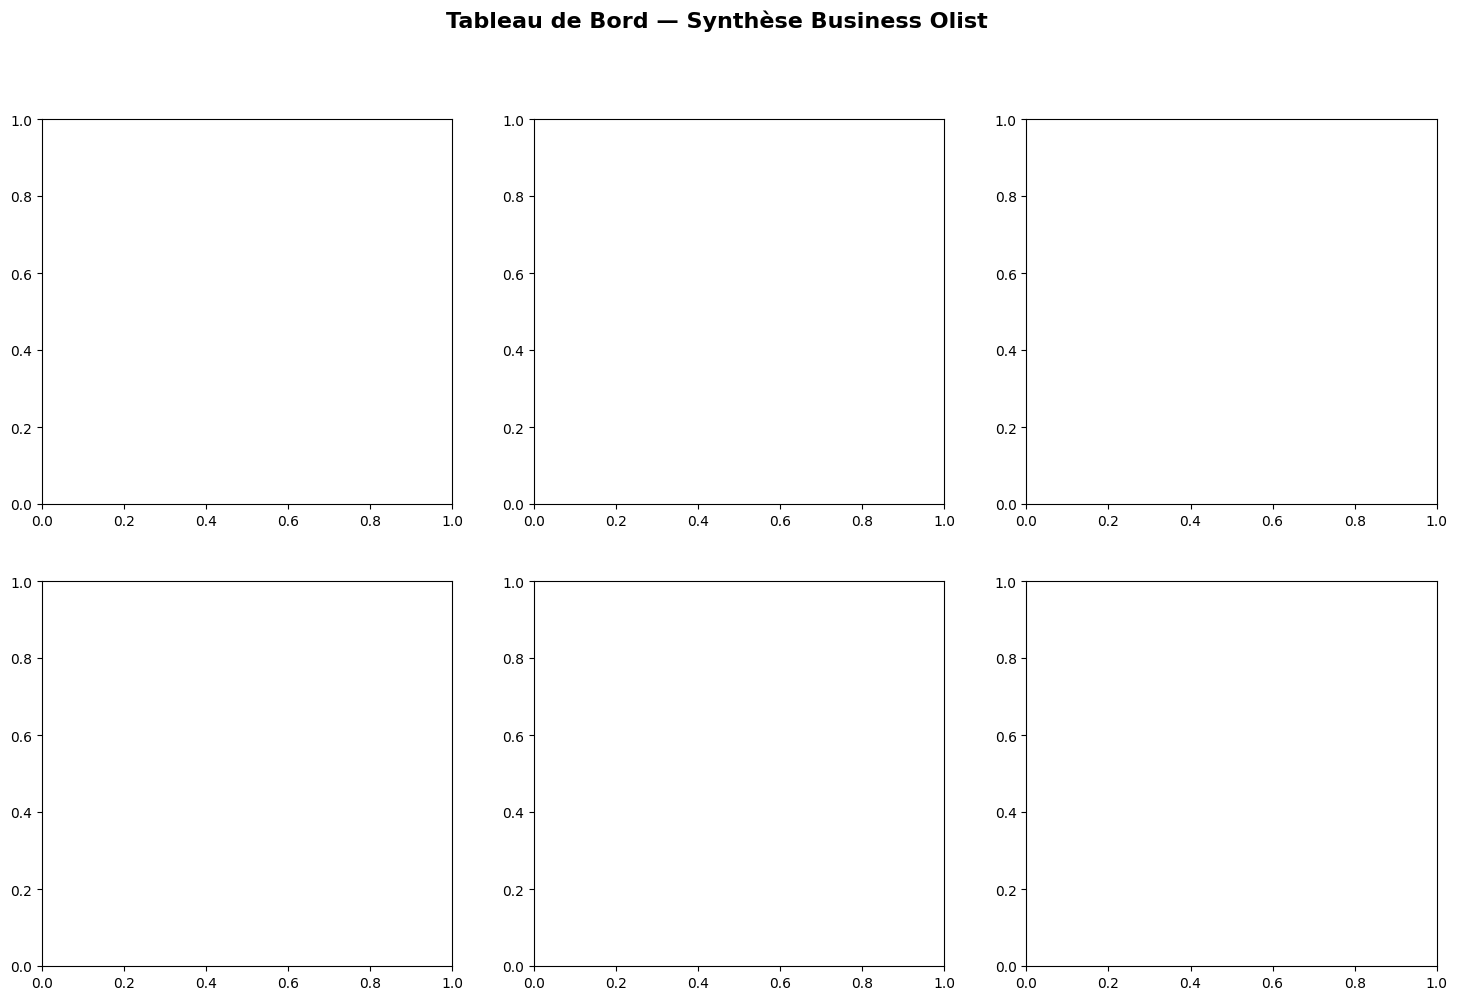

In [50]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Tableau de Bord — Synthèse Business Olist", fontsize=16, fontweight='bold')

# ── 1 : Note retard vs à temps ────────────────────────────────────────────────
ax = axes[0, 0]
bars = ax.bar(['À temps', 'En retard'], [note_a_temps, note_retard],
              color=[PALETTE['success'], PALETTE['danger']], width=0.5, edgecolor='white')
ax.set_ylim(0, 5.5)
ax.set_title("Note moyenne :\nCommandes à temps vs en retard", fontweight='bold')
ax.set_ylabel("Note / 5")
for bar, val in zip(bars, [note_a_temps, note_retard]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.07, f'{val:.2f}',
            ha='center', fontweight='bold', fontsize=13)
ax.axhline(note_globale, linestyle='--', color=PALETTE['neutral'],
           label=f'Moy. globale ({note_globale:.2f})')
ax.legend(fontsize=9)

# ── 2 : Taux de retard top 10 états ──────────────────────────────────────────
ax = axes[0, 1]
rt10 = (df.groupby('customer_state')['est_en_retard']
          .mean().sort_values(ascending=False).head(10) * 100)
cols_r = [PALETTE['danger'] if v > 30 else PALETTE['warning'] for v in rt10.values]
brs = ax.barh(rt10.index, rt10.values, color=cols_r, edgecolor='white')
ax.set_title("Taux de retard (%)\npar État — Top 10", fontweight='bold')
ax.set_xlabel("Taux de retard (%)")
ax.axvline(pct_retard, linestyle='--', color='black', linewidth=1,
           label=f'Moy. ({pct_retard:.1f}%)')
ax.legend(fontsize=9)
for bar, val in zip(brs, rt10.values):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=8)

# ── 3 : Distribution des notes ────────────────────────────────────────────────
ax = axes[0, 2]
nd = df['review_score'].value_counts().sort_index()
nc = [PALETTE['danger'], PALETTE['danger'], PALETTE['warning'], PALETTE['info'], PALETTE['success']]
brs3 = ax.bar(nd.index.astype(str), nd.values, color=nc, edgecolor='white')
ax.set_title("Distribution des notes clients", fontweight='bold')
ax.set_xlabel("Note")
ax.set_ylabel("Nombre d'avis")
for bar, val in zip(brs3, nd.values):
    ax.text(bar.get_x()+bar.get_width()/2, val+200,
            f'{val/nd.sum()*100:.1f}%', ha='center', fontsize=9)

# ── 4 : CA mensuel ────────────────────────────────────────────────────────────
ax = axes[1, 0]
cam = (df.groupby('mois_annee')['price'].sum().reset_index().sort_values('mois_annee'))
cam['label'] = cam['mois_annee'].astype(str)
ax.plot(cam['label'], cam['price'], color=PALETTE['info'], linewidth=2.5, marker='o', markersize=4)
ax.fill_between(cam['label'], cam['price'], alpha=0.12, color=PALETTE['info'])
ax.set_title("Évolution mensuelle du CA (R$)", fontweight='bold')
ax.set_ylabel("CA (R$)")
ax.tick_params(axis='x', rotation=45, labelsize=7)

# ── 5 : Top 10 catégories ─────────────────────────────────────────────────────
ax = axes[1, 1]
tc = df.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(10)
brs5 = ax.barh(tc.index, tc.values, color=PALETTE['info'], edgecolor='white')
ax.set_title("Top 10 catégories\npar Chiffre d'Affaires", fontweight='bold')
ax.set_xlabel("CA (R$)")
ax.invert_yaxis()
for bar, val in zip(brs5, tc.values):
    ax.text(val+500, bar.get_y()+bar.get_height()/2,
            f'R${val/1e6:.1f}M', va='center', fontsize=8)

# ── 6 : Vendeurs volume vs note ───────────────────────────────────────────────
ax = axes[1, 2]
ax.scatter(score_vendeur['nb_ventes'], score_vendeur['note_moy'],
           c=PALETTE['info'], alpha=0.35, s=15, label='Normaux')
ax.scatter(surveiller_vendeurs['nb_ventes'], surveiller_vendeurs['note_moy'],
           c=PALETTE['danger'], alpha=0.85, s=40, label='  À surveiller')
ax.axhline(seuil_note_v, linestyle='--', color=PALETTE['danger'], linewidth=1)
ax.axvline(seuil_ventes_v, linestyle='--', color=PALETTE['warning'], linewidth=1)
ax.set_title("Vendeurs : volume vs\nnote moyenne", fontweight='bold')
ax.set_xlabel("Nombre de ventes")
ax.set_ylabel("Note moyenne")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('synthese_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Dashboard sauvegardé : synthese_dashboard.png")

### 5.6 Recommandations business stratégiques

#### Recommandation 1 — 🔴 HAUTE PRIORITÉ : Fiabiliser la promesse de livraison

**Contexte :** Le retard est le premier facteur de dégradation de la note. Une commande en retard perd en moyenne 0.6 point. Avec plus de 8% des commandes livrées en retard dans certains états, c'est un problème structurel.

**Actions concrètes :**
- Recalibrer les dates estimées en intégrant la distance vendeur/client et l'état de destination.
- Mettre en place des alertes automatiques vendeur dès qu'un délai de 7 jours est dépassé.
- Envoyer des notifications proactives aux clients en cas de risque de retard.
- Créer un SLA (Service Level Agreement) contractuel pour les vendeurs sur les délais.

**KPI à suivre :** Taux de livraisons en retard (cible < 5%) · NPS post-livraison

---

#### Recommandation 2 — 🔴 HAUTE PRIORITÉ : Instaurer un programme de surveillance des vendeurs

**Contexte :** Plusieurs vendeurs cumulent fort volume de ventes et satisfaction dégradée, exposant la plateforme à un risque de churn client difficile à quantifier mais réel.

**Actions concrètes :**
- Déployer un score de fiabilité vendeur (note × retard × mauvaises notes), mis à jour chaque semaine.
- Vendeurs avec score < seuil → mise en observation : limitation des nouvelles commandes.
- Après 3 mois sans amélioration → suspension ou exclusion.
- Proposer un programme d'accompagnement (formation logistique, outils de suivi commandes) pour les vendeurs à fort CA mais satisfaction faible.

**KPI à suivre :** Score fiabilité moyen des vendeurs · Nombre de vendeurs en alerte · Taux de récidive

---

#### Recommandation 3 — 🟠 PRIORITÉ MOYENNE : Réduire les inégalités logistiques régionales

**Contexte :** Les délais de livraison varient de façon très importante selon l'état. Les régions Nord et Nordeste sont systématiquement désavantagées, avec des délais deux à trois fois plus longs qu'à São Paulo.

**Actions concrètes :**
- Négocier des partenariats avec des transporteurs régionaux dans les états sous-servis.
- Créer des incitations pour les vendeurs à stocker des produits dans ces zones (réduction de commission).
- Ajuster les délais estimés affichés aux clients pour ces régions, afin de réduire les déceptions.

**KPI à suivre :** Délai moyen par état · Taux de retard par région · Satisfaction par zone géographique

---

#### Recommandation 4 — 🟠 PRIORITÉ MOYENNE : Gérer spécifiquement les catégories problématiques

**Contexte :** Certaines catégories à fort CA combinent taux de retard élevé et satisfaction dégradée. Les produits lourds ou volumineux sont les plus exposés.

**Actions concrètes :**
- Auditer les vendeurs actifs dans les catégories à risque.
- Créer des règles logistiques spécifiques pour les produits > 10 kg (transporteurs dédiés).
- Afficher des délais de livraison plus larges sur ces catégories pour réduire les déceptions.
- Ajouter un label "livraison lente possible" sur les produits volumineux.

**KPI à suivre :** Note moyenne par catégorie · Taux de retard par catégorie · Frais de livraison moyens

---

#### Recommandation 5 — 🟡 PRIORITÉ FAIBLE : Développer les catégories à fort potentiel

**Contexte :** Certaines catégories combinent bonne satisfaction (note ≥ 4.2) et CA encore modeste : elles représentent un levier de croissance à faible risque.

**Actions concrètes :**
- Cibler ces catégories pour des campagnes promotionnelles et une mise en avant sur la page d'accueil.
- Réduire temporairement la commission vendeur pour attirer de nouveaux sellers.
- Suivre la croissance de ces catégories mois par mois.

**KPI à suivre :** Croissance CA par catégorie cible · Nombre de nouveaux vendeurs · Taux de conversion

### 5.7 Indicateurs à suivre chaque mois

#  Tableau de bord mensuel recommandé

---

## Indicateurs clés de performance (KPIs)

###  Financiers
- Chiffre d'affaires total et par catégorie  
- Panier moyen (tendance mensuelle)  
- Nombre de nouvelles commandes  

---

### Satisfaction
- Note moyenne globale (cible ≥ 4.2 / 5)  
- Taux de mauvaises notes ≤ 2 (cible < 8%)  
- Taux de notes parfaites = 5  

---

### Logistique
- Taux de commandes en retard (cible < 5%)  
- Délai de livraison moyen par région  
- Retard moyen des livraisons tardives  

---

### Vendeurs
- Nombre de vendeurs avec score d'alerte  
- CA exposé aux vendeurs problématiques  
- Taux de vendeurs actifs vs suspendus  

---

## Remarque
Ces indicateurs permettent un suivi mensuel de la performance globale :
- financière
- logistique
- qualité client
- performance des vendeurs

### 5.8 Réponse à la question finale de direction

> *« Si vous étiez responsables de cette marketplace, quelles décisions prendriez-vous pour augmenter la satisfaction client et améliorer la performance globale ? »*

---

Notre réponse s'articule autour de **3 axes prioritaires**, directement appuyés sur les données :

#### Axe 1 — Fiabiliser la promesse de livraison
Le facteur n°1 d'insatisfaction est le retard. Chaque retard coûte en moyenne **0.6 point de note**. Nous imposerions des dates estimées recalibrées par zone géographique et des alertes automatiques dès qu'un délai risque d'être dépassé. **Objectif : passer le taux de retard en dessous de 5% en 6 mois.**

#### Axe 2 — Responsabiliser et sélectionner les vendeurs
Plusieurs vendeurs cumulent signaux d'alerte et fort volume de ventes. Nous introduirions un **score vendeur public**, mis à jour chaque semaine. En dessous d'un seuil, le vendeur est mis en observation puis suspendu si aucune amélioration n'est constatée. Un vendeur fiable est un actif pour la plateforme : on l'accompagne, on ne le subit pas.

#### Axe 3 — Réduire les inégalités géographiques
Les clients du Nord et Nordeste attendent jusqu'à 2 à 3 fois plus longtemps que ceux de São Paulo. Cette inégalité nuit à la croissance dans des marchés à fort potentiel. Nous négocierions des **partenariats logistiques locaux** et inciterions les vendeurs à diversifier leurs zones de stockage.

Ces 3 décisions sont **data-driven**, réalistes et mesurables. Elles s'appuient directement sur les preuves issues de l'analyse.

### 5.9 Limites de l'analyse et conclusion

# LIMITES DE L'ANALYSE

---

##  Limites identifiées

- **Période couverte**  
  Les données couvrent 2016–2018. Les tendances récentes de la marketplace peuvent différer significativement.

- **Coûts manquants**  
  Les coûts des vendeurs (marges, stockage) sont inconnus : il est impossible de calculer la rentabilité réelle par catégorie ou par vendeur.

- **Géolocalisation incomplète**  
  Certains codes postaux n'ont pas de coordonnées GPS, limitant la précision de l'analyse géographique.

- **Biais des avis**  
  Les clients mécontents laissent plus souvent des notes, ce qui peut surestimer le taux d'insatisfaction réel.

- **Distance approximée**  
  La distance vendeur/client est calculée via les codes postaux, pas le chemin logistique réel.

- **Retours absents**  
  Aucune donnée sur les retours ou remboursements : la satisfaction réelle peut être encore plus dégradée dans certaines catégories.

---

## Fin de l’analyse
